# Clustering V3

In [9]:
# Close DuckDB connection
if "con" in globals() and con is not None:
    con.close()
    con = None
    print("DuckDB connection closed.")
else:
    print("No open `con` found.")

DuckDB connection closed.


active: 100,000 sampled rows, 101 clustering features after all-null/zero-variance drops
Saved correlation matrix: outputs/clustering/v3/correlation/active_feature_correlation.csv
Saved top correlated feature pairs: outputs/clustering/v3/correlation/active_top_correlated_feature_pairs.csv


,feature_1,feature_2,abs_corr,corr
0,days_since_last_activity,days_since_last_activity_0_30d,1.000000,1.000000
1,active_non_builder_0_30d,recent_build_flag,1.000000,-1.000000
2,high_effort_count_0_30d,score_effort_misalignment_count_0_30d,0.999770,0.999770
3,clipped_lifetime_activity_score_sum_p99,clipped_lifetime_effort_x_activity_score_sum_p99,0.995095,0.995095
4,lifetime_discover_count,lifetime_api_count,0.994502,0.994502
5,log_lifetime_effort_x_activity_score_sum,log_clipped_lifetime_effort_x_activity_score_s...,0.992138,0.992138
6,log_lifetime_activity_score_sum,log_clipped_lifetime_activity_score_sum_p99,0.991573,0.991573
7,lifetime_avg_effort_rank,lifetime_avg_score_effort_gap,0.991305,-0.991305
8,avg_effort_rank_0_30d,avg_score_effort_gap_0_30d,0.989444,-0.989444
9,score_effort_misalignment_share_lifetime,high_effort_share_lifetime,0.985977,0.985977


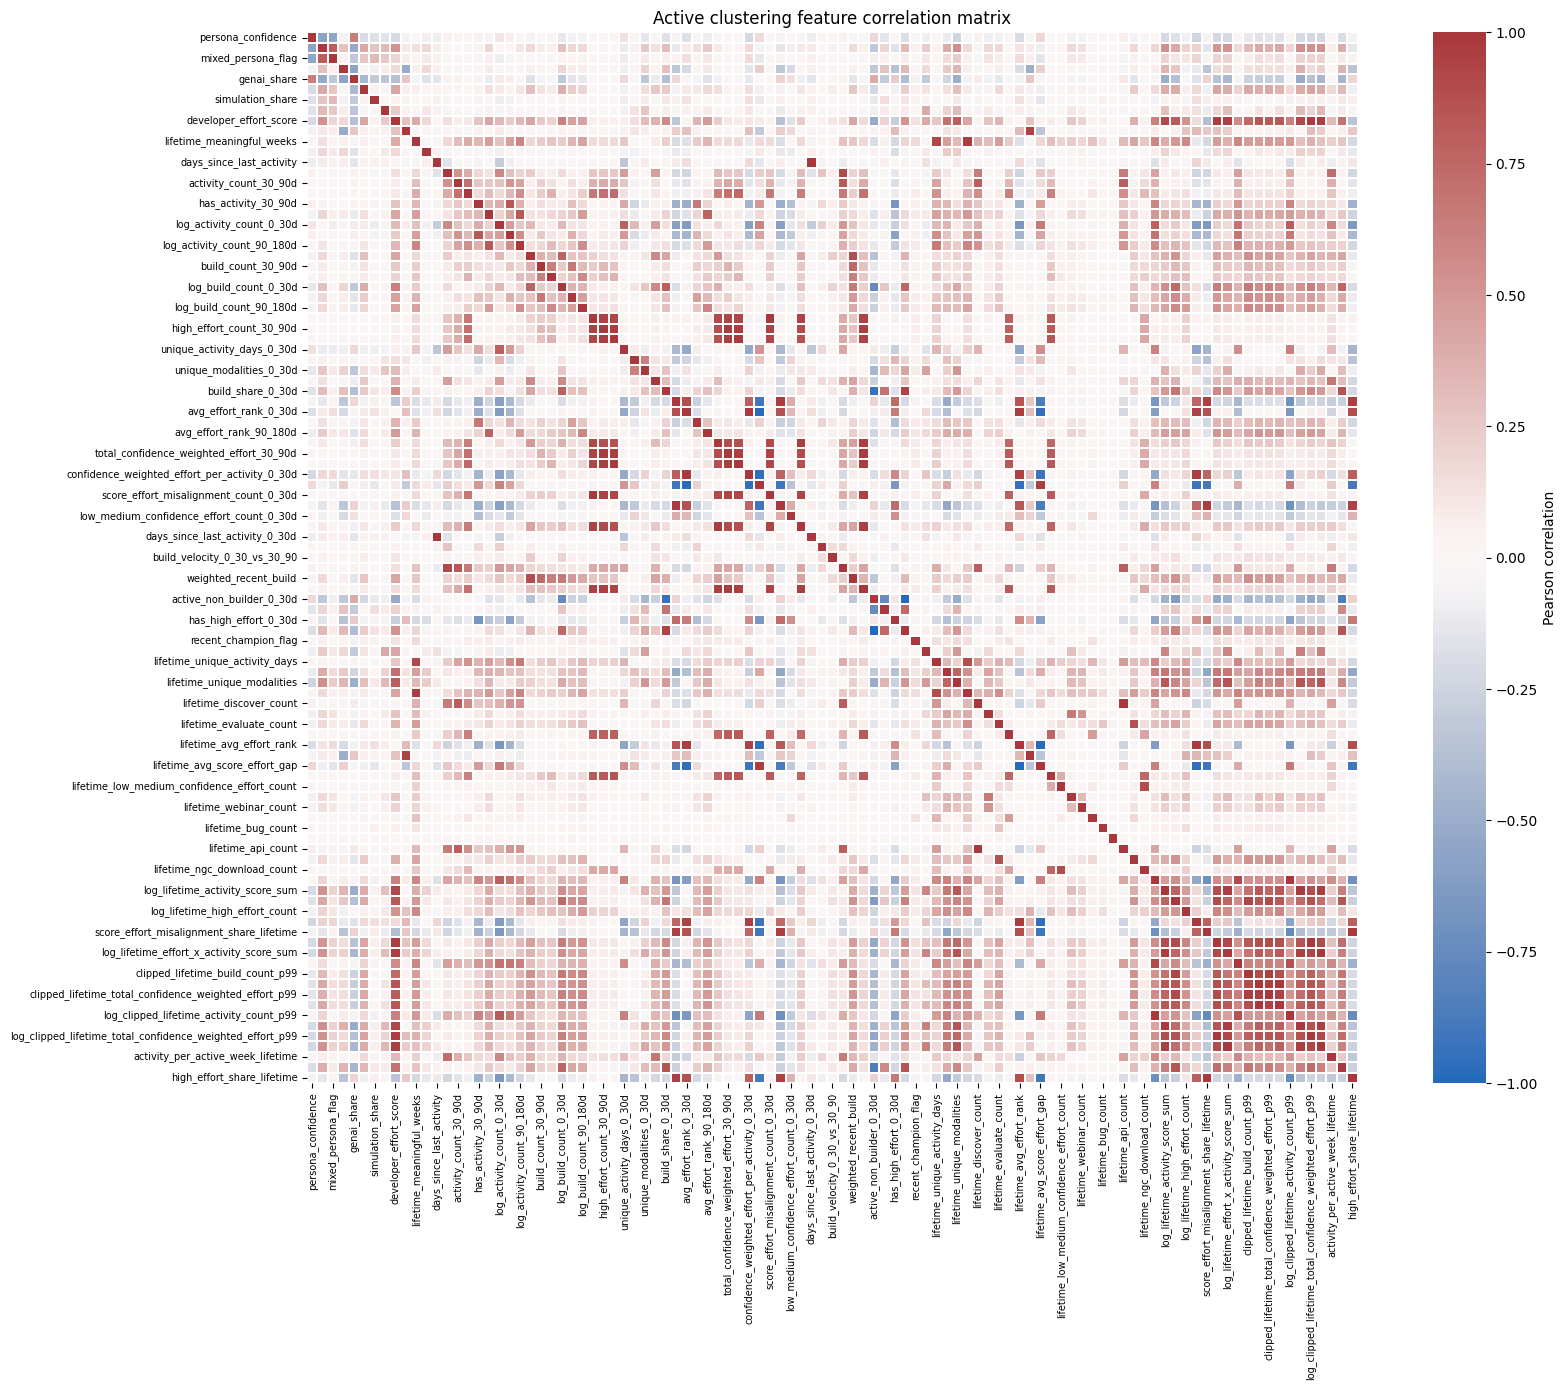

cooling: 100,000 sampled rows, 73 clustering features after all-null/zero-variance drops
Saved correlation matrix: outputs/clustering/v3/correlation/cooling_feature_correlation.csv
Saved top correlated feature pairs: outputs/clustering/v3/correlation/cooling_top_correlated_feature_pairs.csv


,feature_1,feature_2,abs_corr,corr
0,log_lifetime_effort_x_activity_score_sum,log_clipped_lifetime_effort_x_activity_score_s...,0.996274,0.996274
1,log_lifetime_activity_score_sum,log_clipped_lifetime_activity_score_sum_p99,0.995134,0.995134
2,clipped_lifetime_activity_score_sum_p99,clipped_lifetime_effort_x_activity_score_sum_p99,0.994559,0.994559
3,log_lifetime_total_confidence_weighted_effort,log_clipped_lifetime_total_confidence_weighted...,0.991493,0.991493
4,log_lifetime_activity_count,log_clipped_lifetime_activity_count_p99,0.990945,0.990945
5,lifetime_champion_count,lifetime_forum_count,0.981663,0.981663
6,developer_effort_score,log_clipped_lifetime_total_confidence_weighted...,0.979578,0.979578
7,lifetime_avg_effort_rank,lifetime_avg_score_effort_gap,0.975928,-0.975928
8,lifetime_low_medium_confidence_effort_count,lifetime_ngc_download_count,0.975265,0.975265
9,weighted_recent_build,weighted_recent_confidence_effort,0.972497,0.972497


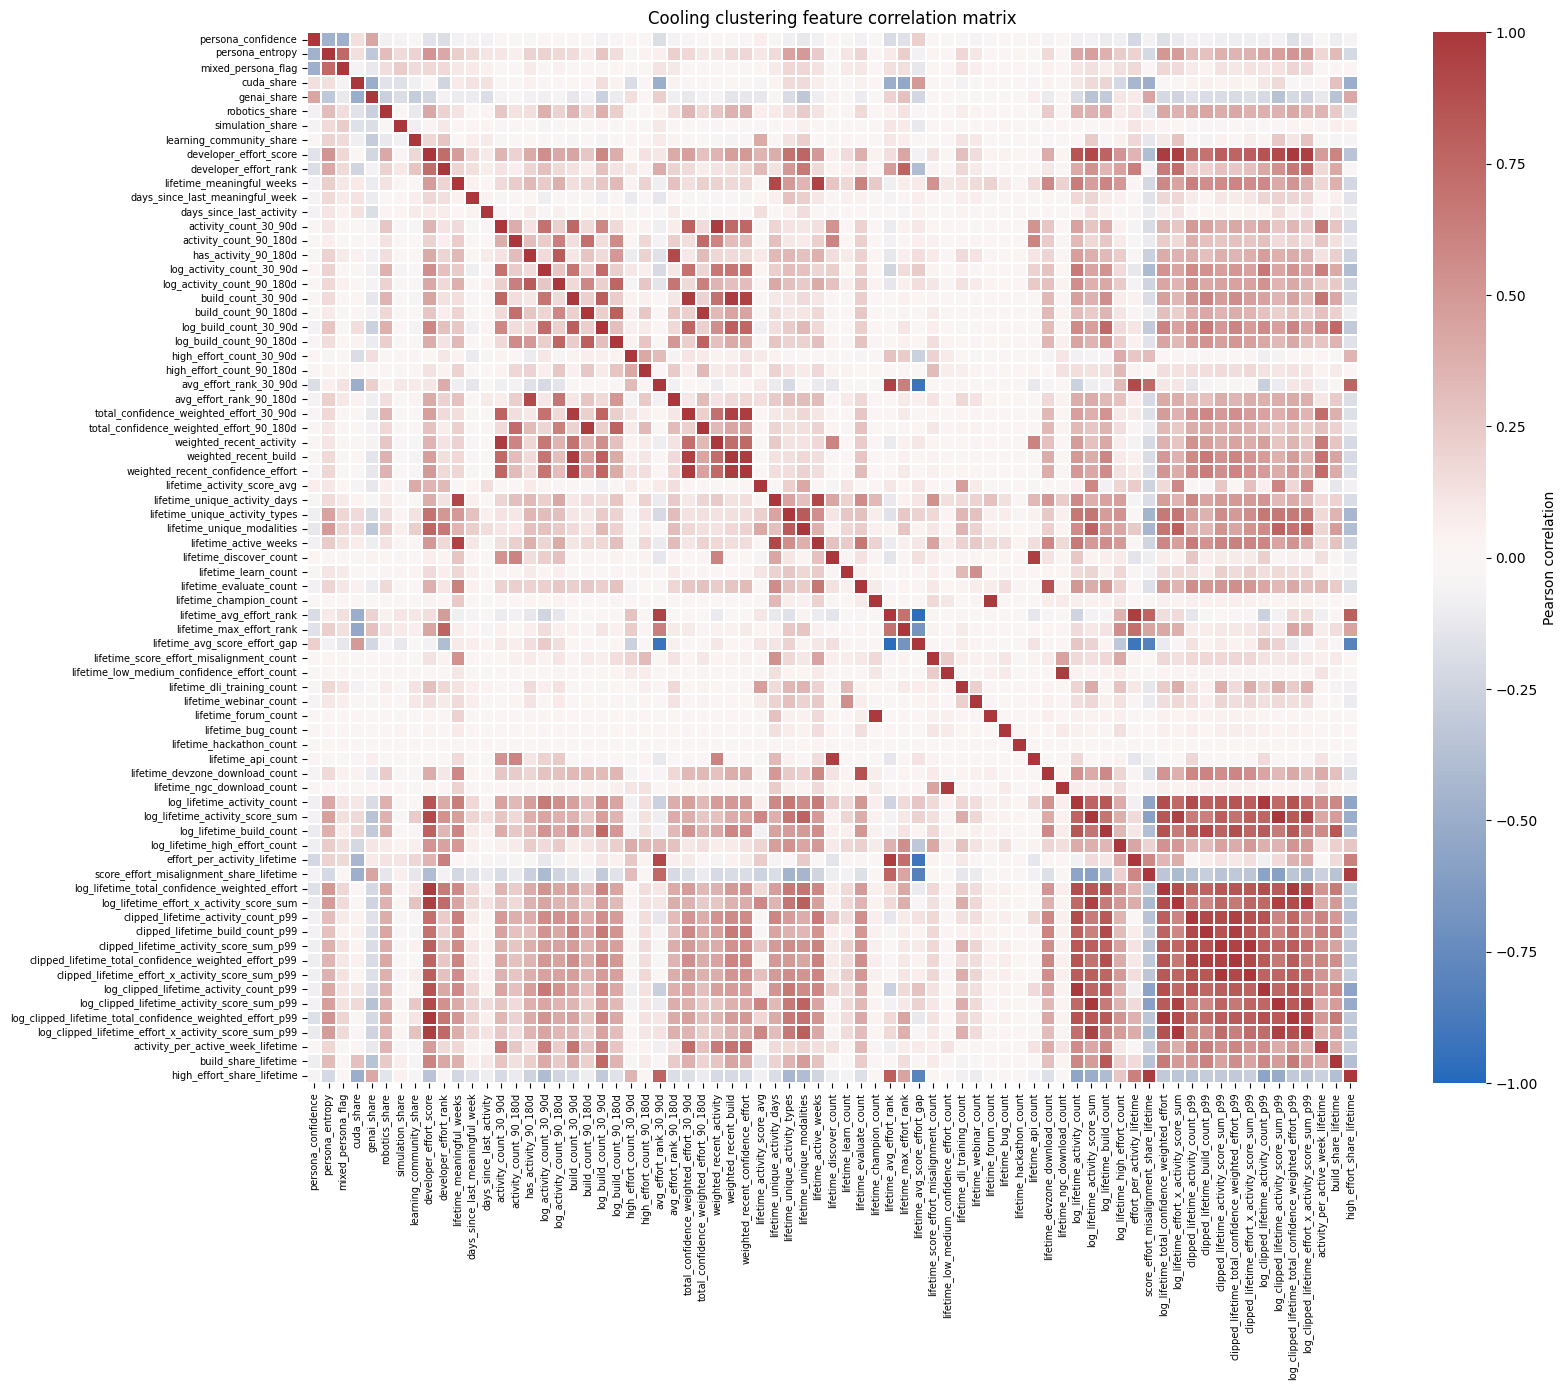

dormant: 100,000 sampled rows, 55 clustering features after all-null/zero-variance drops
Saved correlation matrix: outputs/clustering/v3/correlation/dormant_feature_correlation.csv
Saved top correlated feature pairs: outputs/clustering/v3/correlation/dormant_top_correlated_feature_pairs.csv


,feature_1,feature_2,abs_corr,corr
0,lifetime_score_effort_misalignment_count,lifetime_ngc_download_count,0.999057,0.999057
1,log_lifetime_effort_x_activity_score_sum,log_clipped_lifetime_effort_x_activity_score_s...,0.998743,0.998743
2,log_lifetime_activity_score_sum,log_clipped_lifetime_activity_score_sum_p99,0.998230,0.998230
3,log_lifetime_total_confidence_weighted_effort,log_clipped_lifetime_total_confidence_weighted...,0.996091,0.996091
4,log_lifetime_activity_count,log_clipped_lifetime_activity_count_p99,0.995935,0.995935
5,clipped_lifetime_activity_count_p99,clipped_lifetime_total_confidence_weighted_eff...,0.990713,0.990713
6,clipped_lifetime_activity_score_sum_p99,clipped_lifetime_effort_x_activity_score_sum_p99,0.989458,0.989458
7,lifetime_champion_count,lifetime_forum_count,0.979986,0.979986
8,developer_effort_score,log_clipped_lifetime_total_confidence_weighted...,0.973782,0.973782
9,developer_effort_score,log_lifetime_total_confidence_weighted_effort,0.968383,0.968383


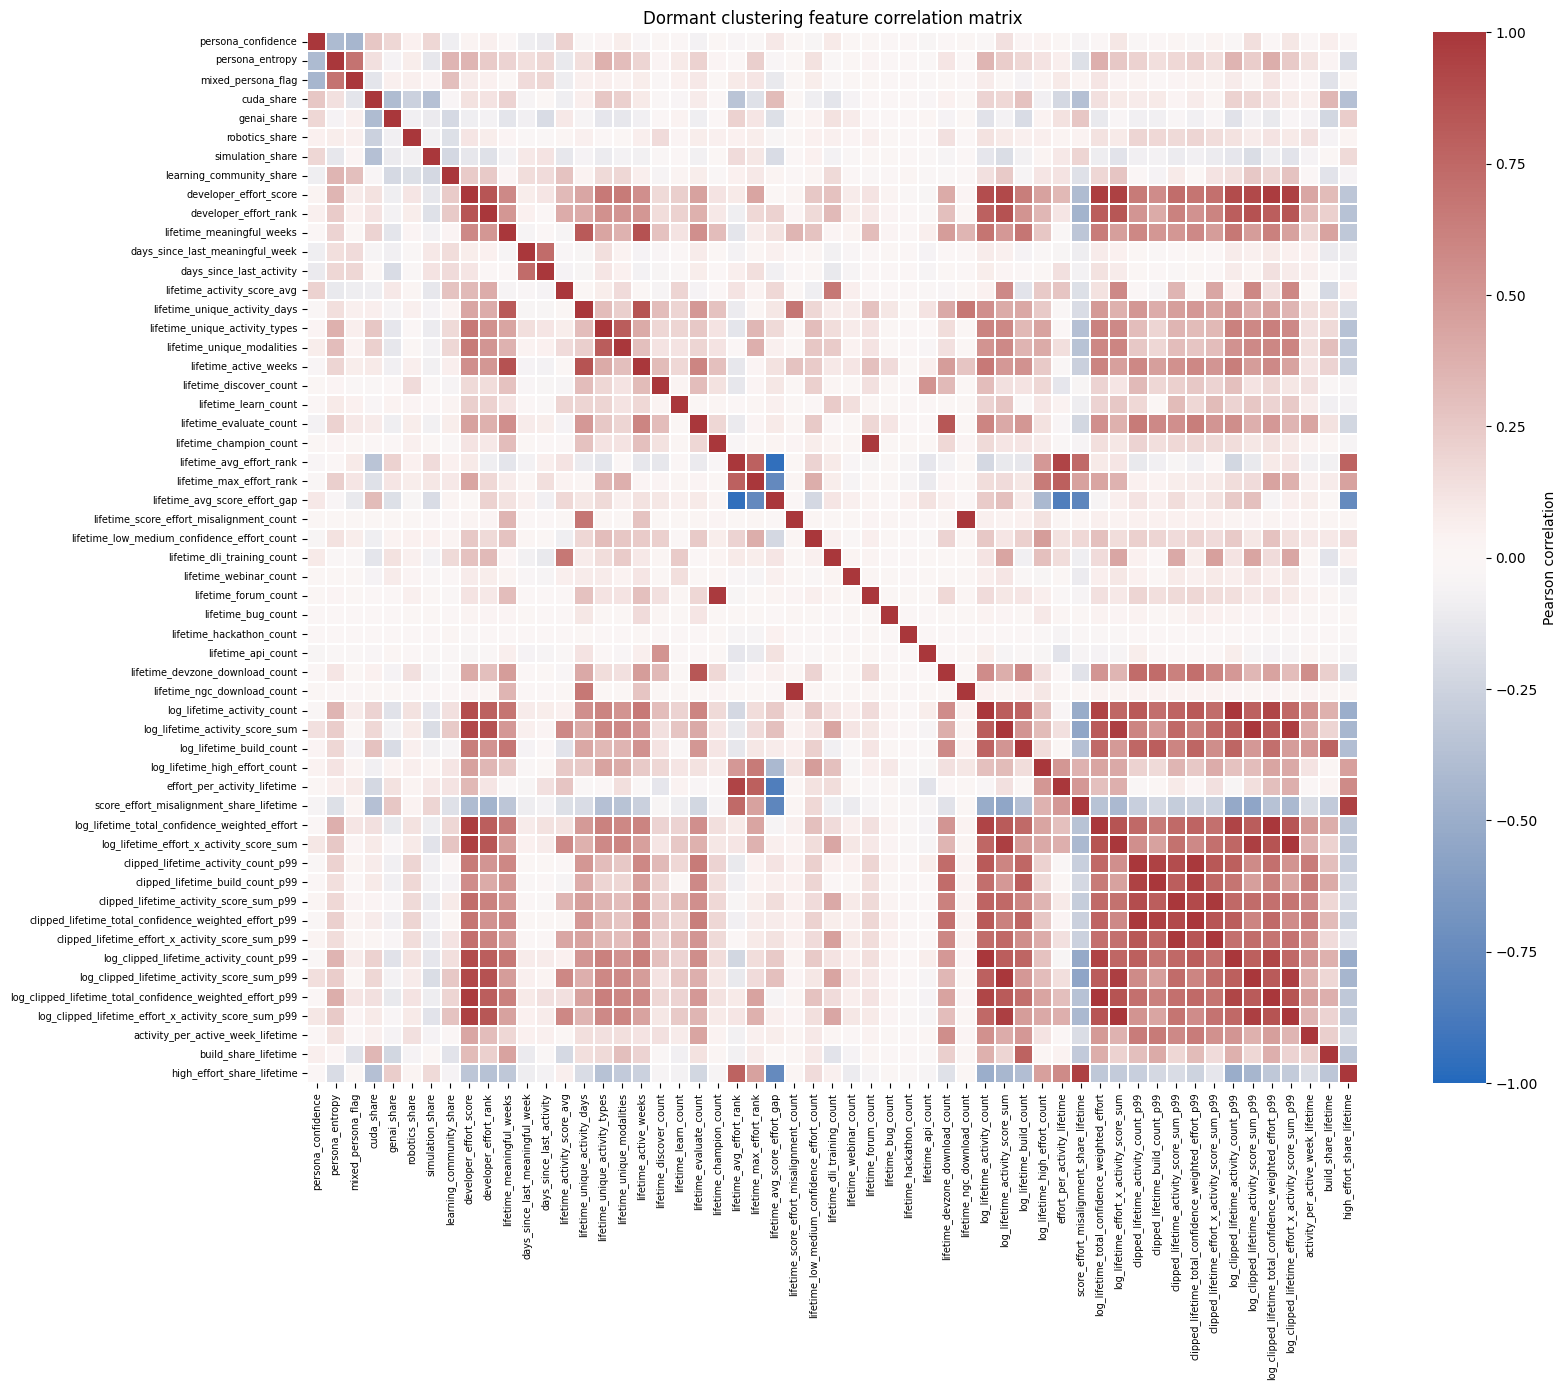

In [4]:
# Correlation matrix for the numeric features used by the clustering pipeline
# This checks the pre-SVD feature space: median-imputed numeric behavioral features,
# after applying the same exclusion rules and dropping zero-variance columns.

from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.impute import SimpleImputer

DB_PATH = "developer_project.duckdb"
OUTPUT_DIR = Path("outputs/clustering/v3/correlation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_N = 100_000
HASH_SALT = 42
PROFILE_TABLE = "dev_profile_final_v4"

# Set to "active", "cooling", "dormant", or "all".
STRATUM_TO_PLOT = "all"

EXCLUDE_EXACT = {
    "developer_id",
    "contact_created_date", "contact_first_activity_date", "contact_last_activity_date",
    "account_id", "account_type", "country", "region", "industry_segment_vertical",
    "program_application_source", "organization_english_name", "normalized_account_name",
    "wwfo_category", "wwfo_target_list",
    "behavior_journey_stage_30d", "behavior_journey_rank_30d",
    "current_journey_state_30d", "current_journey_rank_30d",
    "final_lifecycle_status", "persona", "persona_confidence_tier", "developer_effort_level",
    "dormancy_status", "user_type", "max_stage_reached",
    "last_meaningful_week_start", "lifetime_first_activity_date", "lifetime_last_activity_date",
    "missing_contact_metadata_flag",
}

RAW_LIFETIME_SUPERSEDED = {
    "lifetime_activity_count", "lifetime_activity_score_sum", "lifetime_build_count",
    "lifetime_high_effort_count", "lifetime_total_confidence_weighted_effort",
    "lifetime_effort_x_activity_score_sum",
}

STRATA = {
    "active": (
        "is_activated = 1 AND COALESCE(dormancy_status, '') = 'Active' "
        "AND COALESCE(has_activity_0_30d, 0) = 1"
    ),
    "cooling": "COALESCE(dormancy_status, '') = 'Cooling'",
    "dormant": "COALESCE(dormancy_status, '') = 'Dormant'",
}


def should_exclude(col: str) -> bool:
    if col in EXCLUDE_EXACT or col in RAW_LIFETIME_SUPERSEDED:
        return True
    return col.startswith("first_activity_date") or col.startswith("last_activity_date")


def load_clustering_feature_sample(con: duckdb.DuckDBPyConnection, stratum_key: str) -> pd.DataFrame:
    where_sql = STRATA[stratum_key]
    profile_cols = [
        row[0]
        for row in con.execute(
            f"""
            SELECT column_name
            FROM information_schema.columns
            WHERE table_name = '{PROFILE_TABLE}'
            ORDER BY ordinal_position
            """
        ).fetchall()
    ]
    candidate_cols = [col for col in profile_cols if not should_exclude(col)]
    select_cols = ", ".join(f'"{col}"' for col in candidate_cols)

    # Deterministic sample matching the v2 clustering convention, without creating tables.
    query = f"""
        SELECT {select_cols}
        FROM {PROFILE_TABLE}
        WHERE {where_sql}
        ORDER BY hash(CAST(developer_id AS VARCHAR) || '{HASH_SALT}')
        LIMIT {SAMPLE_N}
    """
    df = con.execute(query).fetchdf()
    numeric_cols = [col for col in df.columns if pd.api.types.is_numeric_dtype(df[col])]
    return df[numeric_cols]


def clustering_feature_correlation(con: duckdb.DuckDBPyConnection, stratum_key: str):
    raw_features = load_clustering_feature_sample(con, stratum_key)

    non_empty_cols = raw_features.columns[raw_features.notna().any()].tolist()
    raw_features = raw_features[non_empty_cols]

    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(raw_features)
    feature_df = pd.DataFrame(X_imputed, columns=raw_features.columns)

    keep_cols = feature_df.columns[feature_df.var(axis=0) > 1e-12].tolist()
    feature_df = feature_df[keep_cols]
    corr = feature_df.corr()

    corr_path = OUTPUT_DIR / f"{stratum_key}_feature_correlation.csv"
    corr.to_csv(corr_path)

    corr_abs = corr.abs()
    upper_mask = np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
    top_pairs = (
        corr_abs.where(upper_mask)
        .stack()
        .sort_values(ascending=False)
        .head(25)
        .reset_index()
        .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_corr"})
    )
    top_pairs["corr"] = [corr.loc[row.feature_1, row.feature_2] for row in top_pairs.itertuples()]
    top_pairs_path = OUTPUT_DIR / f"{stratum_key}_top_correlated_feature_pairs.csv"
    top_pairs.to_csv(top_pairs_path, index=False)

    print(
        f"{stratum_key}: {len(feature_df):,} sampled rows, "
        f"{len(feature_df.columns):,} clustering features after all-null/zero-variance drops"
    )
    print(f"Saved correlation matrix: {corr_path}")
    print(f"Saved top correlated feature pairs: {top_pairs_path}")
    display(top_pairs)

    plt.figure(figsize=(18, 14))
    sns.heatmap(
        corr,
        cmap="vlag",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.1,
        cbar_kws={"label": "Pearson correlation"},
    )
    plt.title(f"{stratum_key.title()} clustering feature correlation matrix")
    plt.xticks(rotation=90, fontsize=7)
    plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    plt.show()

    return corr, top_pairs


con = duckdb.connect(DB_PATH)
strata_to_plot = list(STRATA) if STRATUM_TO_PLOT == "all" else [STRATUM_TO_PLOT]
correlation_results = {
    stratum: clustering_feature_correlation(con, stratum)
    for stratum in strata_to_plot
}
con.close()

Started with 107 clustering candidate features
Selected 36 features with pairwise abs(corr) < 0.5
Max abs correlation remaining: 0.499
Saved selected features: outputs/clustering/v3/feature_selection/v3_selected_features_abs_corr_lt_0_50.csv
Saved dropped-feature audit: outputs/clustering/v3/feature_selection/v3_dropped_features_abs_corr_ge_0_50.csv

Use this v3 feature list:
['log_activity_count_30_90d', 'log_activity_count_0_30d', 'log_activity_count_90_180d', 'log_build_count_0_30d', 'log_clipped_lifetime_total_confidence_weighted_effort_p99', 'avg_effort_rank_0_30d', 'avg_effort_rank_30_90d', 'log_lifetime_high_effort_count', 'activity_per_active_week_lifetime', 'learning_community_share', 'activity_velocity_0_30_vs_30_90', 'effort_per_activity_lifetime', 'build_velocity_0_30_vs_30_90', 'cuda_share', 'developer_effort_rank', 'robotics_share', 'simulation_share', 'days_since_last_meaningful_week', 'total_confidence_weighted_effort_90_180d', 'activity_count_30_90d', 'build_count_90_1

,feature,priority,nonzero_rate,variance,scaled_variance,selection_rank
0,log_activity_count_30_90d,40,0.388157,0.661899,1.377652,1
1,log_activity_count_0_30d,40,0.333333,0.651062,1.355095,2
2,log_activity_count_90_180d,40,0.055590,0.308491,0.308490,3
5,log_build_count_0_30d,40,0.035837,0.107016,0.107015,4
6,log_clipped_lifetime_total_confidence_weighted...,35,0.949803,0.928566,1.442406,5
11,avg_effort_rank_0_30d,30,0.275070,1.335660,3.710156,6
19,avg_effort_rank_30_90d,30,0.338420,1.363323,0.340830,7
21,log_lifetime_high_effort_count,30,0.900317,0.179186,0.179185,8
30,activity_per_active_week_lifetime,20,1.000000,54.879813,24.390947,9
31,learning_community_share,20,0.278860,0.047668,12.202923,10


,dropped_feature,kept_feature,abs_corr,corr,dropped_priority,kept_priority
0,avg_score_effort_gap_0_30d,avg_effort_rank_0_30d,0.995888,-0.995888,30,30
1,log_lifetime_total_confidence_weighted_effort,log_clipped_lifetime_total_confidence_weighted...,0.990186,0.990186,30,35
2,high_effort_count_90_180d,total_confidence_weighted_effort_90_180d,0.971321,0.971321,10,10
3,lifetime_avg_effort_rank,effort_per_activity_lifetime,0.966235,0.966235,10,20
4,weighted_recent_confidence_effort,total_confidence_weighted_effort_90_180d,0.948916,0.948916,0,10
5,high_effort_count_30_90d,total_confidence_weighted_effort_90_180d,0.947929,0.947929,10,10
6,lifetime_avg_score_effort_gap,effort_per_activity_lifetime,0.920269,-0.920269,10,20
7,score_effort_misalignment_count_0_30d,total_confidence_weighted_effort_90_180d,0.908506,0.908506,10,10
8,high_effort_count_0_30d,total_confidence_weighted_effort_90_180d,0.908191,0.908191,10,10
9,total_confidence_weighted_effort_30_90d,total_confidence_weighted_effort_90_180d,0.903060,0.903060,10,10


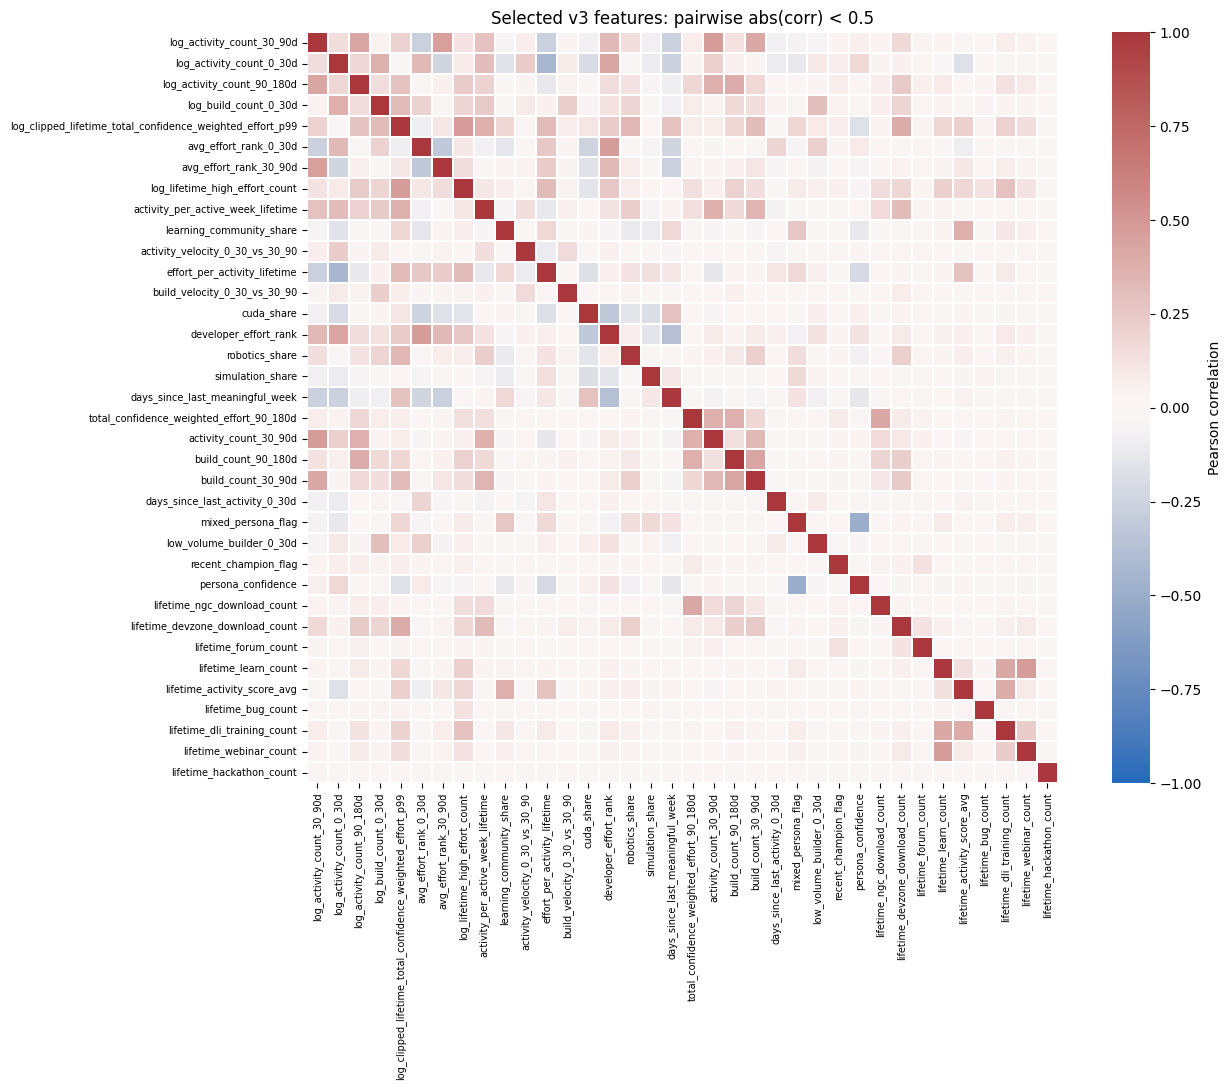

In [5]:
# Build a recommended v3 feature set with pairwise absolute correlation < 0.50
# Run the correlation cell above first so STRATA, load_clustering_feature_sample, and OUTPUT_DIR exist.

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

CORR_THRESHOLD = 0.50
FEATURE_SELECTION_DIR = OUTPUT_DIR.parent / "feature_selection"
FEATURE_SELECTION_DIR.mkdir(parents=True, exist_ok=True)


def _feature_priority(feature: str) -> int:
    """Higher scores are kept first when correlated features compete."""
    score = 0

    # Prefer transformed/capped versions for skewed count-like behavior.
    if feature.startswith("log_clipped_"):
        score += 35
    elif feature.startswith("log_"):
        score += 30
    elif feature.startswith("clipped_"):
        score += 25

    # Prefer normalized behavioral intensity over raw totals when available.
    if any(token in feature for token in ["share", "ratio", "per_", "velocity", "avg_"]):
        score += 20

    # Keep interpretable recency and lifecycle indicators competitive.
    if any(token in feature for token in ["days_since", "has_", "flag", "0_30d", "30_90d", "90_180d"]):
        score += 10

    # Slightly de-prioritize raw lifetime totals because they often duplicate log/clipped versions.
    if feature.startswith("lifetime_"):
        score -= 10

    return score


def _prepare_combined_feature_frame(con: duckdb.DuckDBPyConnection) -> pd.DataFrame:
    frames = []
    for stratum in STRATA:
        frame = load_clustering_feature_sample(con, stratum).copy()
        frame["__stratum"] = stratum
        frames.append(frame)

    combined = pd.concat(frames, ignore_index=True, sort=False)
    features = combined.drop(columns="__stratum")
    features = features.loc[:, features.notna().any(axis=0)]

    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(features)
    feature_df = pd.DataFrame(X_imputed, columns=features.columns)

    # Match the clustering prep: remove columns that carry no usable variation.
    keep_cols = feature_df.columns[feature_df.var(axis=0) > 1e-12].tolist()
    return feature_df[keep_cols]


def select_low_correlation_features(feature_df: pd.DataFrame, threshold: float = CORR_THRESHOLD):
    corr = feature_df.corr()
    abs_corr = corr.abs()

    feature_stats = pd.DataFrame({
        "feature": feature_df.columns,
        "priority": [_feature_priority(col) for col in feature_df.columns],
        "nonzero_rate": [(feature_df[col] != 0).mean() for col in feature_df.columns],
        "variance": [feature_df[col].var() for col in feature_df.columns],
    })

    scaled_for_spread = RobustScaler().fit_transform(feature_df)
    feature_stats["scaled_variance"] = scaled_for_spread.var(axis=0)

    # Deterministic ranking: domain priority first, then signal spread, then sparsity, then name.
    feature_stats = feature_stats.sort_values(
        ["priority", "scaled_variance", "nonzero_rate", "feature"],
        ascending=[False, False, False, True],
    ).reset_index(drop=True)

    selected = []
    dropped = []

    for feature in feature_stats["feature"]:
        if not selected:
            selected.append(feature)
            continue

        max_corr_with_selected = abs_corr.loc[feature, selected].max()
        if max_corr_with_selected < threshold:
            selected.append(feature)
            continue

        kept_feature = abs_corr.loc[feature, selected].idxmax()
        dropped.append({
            "dropped_feature": feature,
            "kept_feature": kept_feature,
            "abs_corr": abs_corr.loc[feature, kept_feature],
            "corr": corr.loc[feature, kept_feature],
            "dropped_priority": feature_stats.loc[feature_stats["feature"] == feature, "priority"].iloc[0],
            "kept_priority": feature_stats.loc[feature_stats["feature"] == kept_feature, "priority"].iloc[0],
        })

    selected_df = feature_stats[feature_stats["feature"].isin(selected)].copy()
    selected_df["selection_rank"] = selected_df["feature"].map({feature: i + 1 for i, feature in enumerate(selected)})
    selected_df = selected_df.sort_values("selection_rank")

    dropped_df = pd.DataFrame(dropped).sort_values("abs_corr", ascending=False).reset_index(drop=True)
    final_corr = corr.loc[selected, selected]
    max_remaining_corr = (
        final_corr.abs()
        .where(np.triu(np.ones(final_corr.shape), k=1).astype(bool))
        .max()
        .max()
    )

    return selected, selected_df, dropped_df, final_corr, max_remaining_corr


con = duckdb.connect(DB_PATH)
feature_df = _prepare_combined_feature_frame(con)
con.close()

v3_selected_features, v3_selected_feature_table, v3_dropped_feature_table, v3_selected_corr, max_selected_abs_corr = (
    select_low_correlation_features(feature_df, CORR_THRESHOLD)
)

selected_path = FEATURE_SELECTION_DIR / "v3_selected_features_abs_corr_lt_0_50.csv"
dropped_path = FEATURE_SELECTION_DIR / "v3_dropped_features_abs_corr_ge_0_50.csv"
corr_path = FEATURE_SELECTION_DIR / "v3_selected_feature_correlation.csv"
list_path = FEATURE_SELECTION_DIR / "v3_selected_features_abs_corr_lt_0_50.txt"

v3_selected_feature_table.to_csv(selected_path, index=False)
v3_dropped_feature_table.to_csv(dropped_path, index=False)
v3_selected_corr.to_csv(corr_path)
list_path.write_text("\n".join(v3_selected_features) + "\n")

print(f"Started with {feature_df.shape[1]:,} clustering candidate features")
print(f"Selected {len(v3_selected_features):,} features with pairwise abs(corr) < {CORR_THRESHOLD}")
print(f"Max abs correlation remaining: {max_selected_abs_corr:.3f}")
print(f"Saved selected features: {selected_path}")
print(f"Saved dropped-feature audit: {dropped_path}")

print("\nUse this v3 feature list:")
print(v3_selected_features)

display(v3_selected_feature_table)
display(v3_dropped_feature_table.head(50))

plt.figure(figsize=(14, 11))
sns.heatmap(
    v3_selected_corr,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.1,
    cbar_kws={"label": "Pearson correlation"},
)
plt.title(f"Selected v3 features: pairwise abs(corr) < {CORR_THRESHOLD}")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

## V3 clustering: reduced correlated features + HDBSCAN

This reruns the v2 clustering design on the same dormancy strata and stratified samples, but removes the SVD step. HDBSCAN fits directly on the median-imputed, robust-scaled feature set selected by the correlation filter above.

In [3]:
# V3 clustering pipeline: stratified sample + correlation-reduced features + HDBSCAN directly on scaled features.
# This mirrors clustering_v2, except it does not apply SVD before HDBSCAN.

import warnings
from dataclasses import dataclass
from pathlib import Path

import duckdb
import hdbscan
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import umap
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

DB_PATH = "developer_project.duckdb"
PROFILE_TABLE = "dev_profile_final_v4"
V3_CLUSTER_OUTPUT_DIR = Path("outputs/clustering/v3")
V3_CLUSTER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SELECTED_FEATURES_PATH = V3_CLUSTER_OUTPUT_DIR / "feature_selection" / "v3_selected_features_abs_corr_lt_0_50.txt"
SAMPLE_N = 100_000
RANDOM_STATE = 42
HASH_SALT = 42
MIN_ROWS = 200
RUN_UMAP_VIZ = False

UMAP_PARAMS = dict(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric="euclidean",
    init="random",
    random_state=RANDOM_STATE,
)

STRATA_ORDER = ["active", "cooling", "dormant"]

EXCLUDE_EXACT = {
    "developer_id",
    "contact_created_date", "contact_first_activity_date", "contact_last_activity_date",
    "account_id", "account_type", "country", "region", "industry_segment_vertical",
    "program_application_source", "organization_english_name", "normalized_account_name",
    "wwfo_category", "wwfo_target_list",
    "behavior_journey_stage_30d", "behavior_journey_rank_30d",
    "current_journey_state_30d", "current_journey_rank_30d",
    "final_lifecycle_status", "persona", "persona_confidence_tier", "developer_effort_level",
    "dormancy_status", "user_type", "max_stage_reached",
    "last_meaningful_week_start", "lifetime_first_activity_date", "lifetime_last_activity_date",
    "missing_contact_metadata_flag",
}

RAW_LIFETIME_SUPERSEDED = {
    "lifetime_activity_count", "lifetime_activity_score_sum", "lifetime_build_count",
    "lifetime_high_effort_count", "lifetime_total_confidence_weighted_effort",
    "lifetime_effort_x_activity_score_sum",
}

PROFILE_COLS = [
    "activity_count_0_30d", "log_activity_count_0_30d", "log_activity_count_30_90d",
    "build_count_0_30d", "log_build_count_0_30d", "log_build_count_30_90d",
    "lifetime_learn_count", "lifetime_build_count", "lifetime_champion_count",
    "lifetime_discover_count", "developer_effort_score", "days_since_last_activity",
    "cuda_share", "genai_share", "robotics_share", "simulation_share",
]

STRATA = {
    "active": {
        "label": "Active (recent 30d activity)",
        "where_sql": (
            "is_activated = 1 AND COALESCE(dormancy_status, '') = 'Active' "
            "AND COALESCE(has_activity_0_30d, 0) = 1"
        ),
        "stratify_col": "persona",
        "min_cluster_frac": 0.005,
        "min_samples": 15,
    },
    "cooling": {
        "label": "Cooling",
        "where_sql": "COALESCE(dormancy_status, '') = 'Cooling'",
        "stratify_col": "persona",
        "min_cluster_frac": 0.007,
        "min_samples": 20,
    },
    "dormant": {
        "label": "Dormant",
        "where_sql": "COALESCE(dormancy_status, '') = 'Dormant'",
        "stratify_col": "persona",
        "min_cluster_frac": 0.007,
        "min_samples": 25,
    },
}


def should_exclude(col: str) -> bool:
    if col in EXCLUDE_EXACT or col in RAW_LIFETIME_SUPERSEDED:
        return True
    return col.startswith("first_activity_date") or col.startswith("last_activity_date")


CORR_THRESHOLD = 0.50


def _feature_priority(feature: str) -> int:
    """Higher scores are kept first when correlated features compete."""
    score = 0
    if feature.startswith("log_clipped_"):
        score += 35
    elif feature.startswith("log_"):
        score += 30
    elif feature.startswith("clipped_"):
        score += 25
    if any(token in feature for token in ["share", "ratio", "per_", "velocity", "avg_"]):
        score += 20
    if any(token in feature for token in ["days_since", "has_", "flag", "0_30d", "30_90d", "90_180d"]):
        score += 10
    if feature.startswith("lifetime_"):
        score -= 10
    return score


def _candidate_feature_sample(con, stratum_key: str) -> pd.DataFrame:
    profile_cols = [r[0] for r in con.execute(
        "SELECT column_name FROM information_schema.columns "
        f"WHERE table_name = '{PROFILE_TABLE}' ORDER BY ordinal_position"
    ).fetchall()]
    candidate_cols = [col for col in profile_cols if not should_exclude(col)]
    select_cols = ", ".join(f'"{col}"' for col in candidate_cols)
    where_sql = STRATA[stratum_key]["where_sql"]
    query = f"""
        SELECT {select_cols}
        FROM {PROFILE_TABLE}
        WHERE {where_sql}
        ORDER BY hash(CAST(developer_id AS VARCHAR) || '{HASH_SALT}')
        LIMIT {SAMPLE_N}
    """
    df = con.execute(query).fetchdf()
    numeric_cols = [col for col in df.columns if pd.api.types.is_numeric_dtype(df[col])]
    return df[numeric_cols]


def _compute_v3_selected_features(con) -> list[str]:
    frames = [_candidate_feature_sample(con, stratum).copy() for stratum in STRATA_ORDER]
    features = pd.concat(frames, ignore_index=True, sort=False)
    features = features.loc[:, features.notna().any(axis=0)]

    imputer = SimpleImputer(strategy="median")
    feature_df = pd.DataFrame(imputer.fit_transform(features), columns=features.columns)
    feature_df = feature_df.loc[:, feature_df.var(axis=0) > 1e-12]

    corr = feature_df.corr()
    abs_corr = corr.abs()
    scaled_variance = RobustScaler().fit_transform(feature_df).var(axis=0)
    feature_stats = pd.DataFrame({
        "feature": feature_df.columns,
        "priority": [_feature_priority(col) for col in feature_df.columns],
        "nonzero_rate": [(feature_df[col] != 0).mean() for col in feature_df.columns],
        "scaled_variance": scaled_variance,
    }).sort_values(
        ["priority", "scaled_variance", "nonzero_rate", "feature"],
        ascending=[False, False, False, True],
    )

    selected = []
    dropped = []
    for feature in feature_stats["feature"]:
        if not selected:
            selected.append(feature)
            continue
        max_corr_with_selected = abs_corr.loc[feature, selected].max()
        if max_corr_with_selected < CORR_THRESHOLD:
            selected.append(feature)
            continue
        kept_feature = abs_corr.loc[feature, selected].idxmax()
        dropped.append({
            "dropped_feature": feature,
            "kept_feature": kept_feature,
            "abs_corr": abs_corr.loc[feature, kept_feature],
            "corr": corr.loc[feature, kept_feature],
        })

    feature_selection_dir = SELECTED_FEATURES_PATH.parent
    feature_selection_dir.mkdir(parents=True, exist_ok=True)
    selected_df = feature_stats[feature_stats["feature"].isin(selected)].copy()
    selected_df["selection_rank"] = selected_df["feature"].map({feature: i + 1 for i, feature in enumerate(selected)})
    selected_df = selected_df.sort_values("selection_rank")
    dropped_df = pd.DataFrame(dropped).sort_values("abs_corr", ascending=False).reset_index(drop=True)

    selected_df.to_csv(feature_selection_dir / "v3_selected_features_abs_corr_lt_0_50.csv", index=False)
    dropped_df.to_csv(feature_selection_dir / "v3_dropped_features_abs_corr_ge_0_50.csv", index=False)
    corr.loc[selected, selected].to_csv(feature_selection_dir / "v3_selected_feature_correlation.csv")
    SELECTED_FEATURES_PATH.write_text("\n".join(selected) + "\n")
    return selected


def load_v3_selected_features(con=None) -> list[str]:
    if "v3_selected_features" in globals() and v3_selected_features:
        return list(v3_selected_features)
    if SELECTED_FEATURES_PATH.exists():
        return [line.strip() for line in SELECTED_FEATURES_PATH.read_text().splitlines() if line.strip()]
    if con is None:
        temp_con = duckdb.connect(DB_PATH)
        try:
            return _compute_v3_selected_features(temp_con)
        finally:
            temp_con.close()
    print(f"Selected-feature file not found; computing abs(corr) < {CORR_THRESHOLD} feature set first...")
    return _compute_v3_selected_features(con)


@dataclass
class StratumRunResult:
    stratum_key: str
    cohort_n: int
    sample_n: int
    n_features: int
    n_clusters: int
    noise_pct: float
    min_cluster_size: int
    output_dir: Path
    skipped: bool = False
    skip_reason: str = ""


def _sample_stratum(con, stratum_key, where_sql, stratify_col, sample_target, hash_salt):
    view = f"clustering_cohort_v3_{stratum_key}"
    sample_table = f"clustering_sample_v3_{stratum_key}"
    con.execute(f"CREATE OR REPLACE VIEW {view} AS SELECT * FROM {PROFILE_TABLE} WHERE {where_sql}")
    cohort_n = con.execute(f"SELECT COUNT(*) FROM {view}").fetchone()[0]
    target = min(sample_target, cohort_n)
    if cohort_n == 0:
        return 0, 0, sample_table
    if cohort_n <= target:
        con.execute(f"CREATE OR REPLACE TABLE {sample_table} AS SELECT * FROM {view}")
        return cohort_n, cohort_n, sample_table
    con.execute(f"""
        CREATE OR REPLACE TABLE {sample_table} AS
        WITH cohort AS (SELECT * FROM {view}),
        targets AS (
            SELECT {stratify_col}, COUNT(*) AS stratum_n,
                GREATEST(1, CAST(ROUND(COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () * {target}) AS BIGINT)) AS target_n
            FROM cohort GROUP BY {stratify_col}
        ),
        ranked AS (
            SELECT c.*,
                ROW_NUMBER() OVER (PARTITION BY c.{stratify_col} ORDER BY hash(c.developer_id || '{hash_salt}')) AS rn,
                t.target_n
            FROM cohort c JOIN targets t USING ({stratify_col})
        )
        SELECT * EXCLUDE (rn, target_n) FROM ranked WHERE rn <= target_n
    """)
    sample_n = con.execute(f"SELECT COUNT(*) FROM {sample_table}").fetchone()[0]
    if sample_n > target:
        con.execute(f"""
            CREATE OR REPLACE TABLE {sample_table} AS
            SELECT * EXCLUDE (rn) FROM (
                SELECT *, ROW_NUMBER() OVER (ORDER BY hash(developer_id || '{hash_salt}')) AS rn
                FROM {sample_table}
            ) WHERE rn <= {target}
        """)
        sample_n = con.execute(f"SELECT COUNT(*) FROM {sample_table}").fetchone()[0]
    return cohort_n, sample_n, sample_table


def _build_reduced_feature_matrices(con, sample_table, selected_features):
    profile_cols = [r[0] for r in con.execute(
        "SELECT column_name FROM information_schema.columns "
        f"WHERE table_name = '{PROFILE_TABLE}' ORDER BY ordinal_position"
    ).fetchall()]
    sample_cols = [r[0] for r in con.execute(
        "SELECT column_name FROM information_schema.columns "
        f"WHERE table_name = '{sample_table}' ORDER BY ordinal_position"
    ).fetchall()]

    selected_set = set(selected_features)
    candidate = [
        c for c in profile_cols
        if c in sample_cols and c in selected_set and not should_exclude(c)
    ]
    df = con.execute(f"SELECT * FROM {sample_table}").fetchdf()
    numeric_cols = [c for c in candidate if pd.api.types.is_numeric_dtype(df[c])]
    numeric_cols = [c for c in numeric_cols if df[c].notna().any()]

    if not numeric_cols:
        raise ValueError(f"No usable selected numeric features found for {sample_table}")

    preprocessor = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ])
    X_scaled = preprocessor.fit_transform(df[numeric_cols])
    keep = np.var(X_scaled, axis=0) > 1e-12
    feature_names = [numeric_cols[i] for i, k in enumerate(keep) if k]
    X_scaled = X_scaled[:, keep]

    if X_scaled.shape[1] == 0:
        raise ValueError(f"All selected features were zero-variance for {sample_table}")

    missing_selected = [c for c in selected_features if c not in feature_names]
    return df, X_scaled, feature_names, missing_selected, preprocessor


def _behavioral_segment_name(g, stratum_key):
    def m(col):
        return float(g[col].mean()) if col in g.columns and g[col].notna().any() else 0.0

    learn = m("lifetime_learn_count") + m("log_activity_count_0_30d")
    build = m("lifetime_build_count") + m("build_count_0_30d") + m("log_build_count_0_30d")
    champ = m("lifetime_champion_count")
    discover = m("lifetime_discover_count")
    recent = m("activity_count_0_30d")

    if build >= max(learn, champ, discover, 1e-9) and build > 0:
        base = "Builders"
    elif champ >= max(learn, build, discover, 1e-9) and champ > 0:
        base = "Champions"
    elif learn >= max(build, champ, discover, 1e-9) and learn > 0:
        base = "Learners"
    elif discover >= max(learn, build, champ, 1e-9) and discover > 0:
        base = "Explorers"
    elif recent > 0:
        base = "Active_Mixed"
    else:
        base = "Low_Signal"

    if stratum_key == "dormant" and build > learn and build > 0:
        return f"Dormant_Former_{base}"
    if stratum_key == "cooling":
        return f"Cooling_{base}"
    return base


def _segment_description(row, stratum_key):
    if row.get("noise_flag"):
        return "Sparse or heterogeneous; not assigned to a dense HDBSCAN cluster."
    name = row.get("behavioral_segment_name", "Segment")
    persona = row.get("top_persona", "")
    journey = row.get("top_journey_state_30d", "")
    n = row.get("n", 0)
    pct = row.get("pct_of_sample", 0)
    return (
        f"{name} ({stratum_key}): n={n:,} ({pct}% of sample). "
        f"Dominant persona {persona}. Typical journey {journey}."
    )


def build_cluster_summary(df, labels, stratum_key, sample_n):
    tmp = df.copy()
    tmp["hdbscan_cluster"] = labels
    profile_cols = [c for c in PROFILE_COLS if c in tmp.columns]
    rows = []
    for cid, g in tmp.groupby("hdbscan_cluster", observed=True):
        row = {
            "dormancy_segment": stratum_key,
            "hdbscan_cluster": int(cid),
            "n": len(g),
            "pct_of_sample": round(100.0 * len(g) / sample_n, 2),
            "noise_flag": int(cid == -1),
        }
        if cid >= 0 and len(g):
            persona_counts = g["persona"].value_counts()
            row["top_persona"] = persona_counts.index[0]
            row["top_persona_pct"] = round(100.0 * persona_counts.iloc[0] / len(g), 2)
            if "current_journey_state_30d" in g.columns and g["current_journey_state_30d"].notna().any():
                row["top_journey_state_30d"] = g["current_journey_state_30d"].mode().iloc[0]
            if "final_lifecycle_status" in g.columns and g["final_lifecycle_status"].notna().any():
                row["top_lifecycle_status"] = g["final_lifecycle_status"].mode().iloc[0]
            if "dormancy_status" in g.columns:
                row["top_dormancy_status"] = g["dormancy_status"].mode().iloc[0]
            row["behavioral_segment_name"] = _behavioral_segment_name(g, stratum_key)
        else:
            row["top_persona"] = ""
            row["top_persona_pct"] = 0.0
            row["top_journey_state_30d"] = ""
            row["top_lifecycle_status"] = ""
            row["top_dormancy_status"] = ""
            row["behavioral_segment_name"] = "Unclustered_Noise"
        for c in profile_cols:
            val = g[c].mean()
            row[f"mean_{c}"] = None if pd.isna(val) else float(val)
        row["segment_description"] = _segment_description(row, stratum_key)
        rows.append(row)
    return pd.DataFrame(rows).sort_values(["noise_flag", "n"], ascending=[True, False])


def run_v3_stratum(con, stratum_key, selected_features, fit_umap=False):
    cfg = STRATA[stratum_key]
    out_dir = V3_CLUSTER_OUTPUT_DIR / stratum_key
    out_dir.mkdir(parents=True, exist_ok=True)

    cohort_n, sample_n, sample_table = _sample_stratum(
        con, stratum_key, cfg["where_sql"], cfg["stratify_col"], SAMPLE_N, HASH_SALT
    )
    if cohort_n == 0:
        return StratumRunResult(stratum_key, 0, 0, 0, 0, 0.0, 0, out_dir, True, "empty cohort")
    if sample_n < MIN_ROWS:
        return StratumRunResult(stratum_key, cohort_n, sample_n, 0, 0, 0.0, 0, out_dir, True, f"n < {MIN_ROWS}")

    df, X_scaled, feature_names, missing_selected, preprocessor = _build_reduced_feature_matrices(
        con, sample_table, selected_features
    )
    mcs = max(30, int(sample_n * cfg["min_cluster_frac"]))
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=cfg["min_samples"],
        metric="euclidean",
        cluster_selection_method="eom",
    )
    labels = clusterer.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = round(100.0 * (labels == -1).sum() / len(labels), 2)

    results = pd.DataFrame({
        "developer_id": df["developer_id"].values,
        "dormancy_segment": stratum_key,
        "hdbscan_cluster": labels,
        "hdbscan_probability": getattr(clusterer, "probabilities_", np.ones(len(labels))),
        "noise_flag": (labels == -1).astype(int),
        "persona": df["persona"].values,
        "dormancy_status": df["dormancy_status"].values,
        "current_journey_state_30d": df["current_journey_state_30d"].values,
        "final_lifecycle_status": df["final_lifecycle_status"].values,
        "behavior_journey_stage_30d": df["behavior_journey_stage_30d"].values,
    })

    if fit_umap:
        emb = umap.UMAP(**UMAP_PARAMS).fit_transform(X_scaled)
        results["umap_x"] = emb[:, 0]
        results["umap_y"] = emb[:, 1]

    summary = build_cluster_summary(df, labels, stratum_key, sample_n)
    results.to_parquet(out_dir / "cluster_results.parquet", index=False)
    summary.to_csv(out_dir / "cluster_summary_table.csv", index=False)
    joblib.dump(
        {
            "preprocessor": preprocessor,
            "feature_names": feature_names,
            "dropped_selected_features_for_this_stratum": missing_selected,
            "method": "hdbscan_on_corr_reduced_scaled_features_no_svd",
        },
        out_dir / "preprocessor.joblib",
    )

    pd.Series(feature_names, name="feature").to_csv(out_dir / "features_used.csv", index=False)
    con.register(f"clusters_v3_{stratum_key}", results)
    con.execute(f"DROP TABLE IF EXISTS developer_clusters_v3_{stratum_key}")
    con.execute(f"CREATE TABLE developer_clusters_v3_{stratum_key} AS SELECT * FROM clusters_v3_{stratum_key}")
    con.unregister(f"clusters_v3_{stratum_key}")

    return StratumRunResult(stratum_key, cohort_n, sample_n, X_scaled.shape[1], n_clusters, noise_pct, mcs, out_dir)


con = duckdb.connect(DB_PATH)
selected_features = load_v3_selected_features(con)
print(f"Loaded {len(selected_features):,} selected v3 features")
print(f"Output: {V3_CLUSTER_OUTPUT_DIR.resolve()}")

run_results = []
result_frames = []

for key in STRATA_ORDER:
    print(f"\n{'=' * 60}\nStratum: {key} - {STRATA[key]['label']}\n{'=' * 60}")
    res = run_v3_stratum(con, key, selected_features, fit_umap=RUN_UMAP_VIZ)
    run_results.append({k: v for k, v in res.__dict__.items() if k != "output_dir"})
    print(
        f"  cohort_n={res.cohort_n:,}  sample_n={res.sample_n:,}  "
        f"features={res.n_features}  clusters={res.n_clusters}  noise={res.noise_pct}%"
        + (f"  SKIPPED: {res.skip_reason}" if res.skipped else "")
    )
    if not res.skipped:
        result_frames.append(pd.read_parquet(res.output_dir / "cluster_results.parquet"))

run_summary_df = pd.DataFrame(run_results)
run_summary_df.to_csv(V3_CLUSTER_OUTPUT_DIR / "run_summary.csv", index=False)
display(run_summary_df)

if result_frames:
    combined_results = pd.concat(result_frames, ignore_index=True)
    combined_results.to_parquet(V3_CLUSTER_OUTPUT_DIR / "cluster_results_all.parquet", index=False)

    summary_parts = [
        pd.read_csv(V3_CLUSTER_OUTPUT_DIR / key / "cluster_summary_table.csv")
        for key in STRATA_ORDER
        if (V3_CLUSTER_OUTPUT_DIR / key / "cluster_summary_table.csv").exists()
    ]
    summary_all = pd.concat(summary_parts, ignore_index=True)
    summary_all.to_csv(V3_CLUSTER_OUTPUT_DIR / "cluster_summary_table_all.csv", index=False)

    con.register("developer_clusters_v3_df", combined_results)
    con.execute("DROP TABLE IF EXISTS developer_clusters_v3")
    con.execute("CREATE TABLE developer_clusters_v3 AS SELECT * FROM developer_clusters_v3_df")
    con.unregister("developer_clusters_v3_df")

    print(f"Combined: {len(combined_results):,} developers with cluster labels")
    print("DuckDB table: developer_clusters_v3")
else:
    print("No strata completed.")

con.close()

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 36 selected v3 features
Output: /Users/pmazolew/Documents/GitHub/Spring2026_IndustryProject/outputs/clustering/v3

Stratum: active - Active (recent 30d activity)


Python(74192) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(74193) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(74194) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(74195) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(74196) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Python(74197) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  cohort_n=418,049  sample_n=99,999  features=36  clusters=60  noise=25.58%

Stratum: cooling - Cooling
  cohort_n=356,500  sample_n=100,000  features=28  clusters=27  noise=25.12%

Stratum: dormant - Dormant
  cohort_n=5,304,852  sample_n=100,000  features=21  clusters=39  noise=39.08%


,stratum_key,cohort_n,sample_n,n_features,n_clusters,noise_pct,min_cluster_size,skipped,skip_reason
0,active,418049,99999,36,60,25.58,499,False,
1,cooling,356500,100000,28,27,25.12,700,False,
2,dormant,5304852,100000,21,39,39.08,700,False,


Combined: 299,999 developers with cluster labels
DuckDB table: developer_clusters_v3


## V3 alternative: correlation groups instead of greedy pairwise filtering

This groups features into connected components where features are linked if `abs(correlation) >= 0.50`, then keeps one representative per group. The representative is chosen by the same priority logic used above: prefer transformed/normalized features, then stronger scaled variation, then less sparse features.

Started with 107 candidate clustering features
Built 16 correlation groups using abs(corr) >= 0.5
Selected 16 representative features
Max abs(corr) among representatives: 0.480
Saved group table: outputs/clustering/v3/feature_selection_grouped/v3_correlation_groups_abs_corr_ge_0_50.csv


,correlation_group,n_features_in_group,candidate_features,recommended_feature,max_abs_corr_in_group,reason
0,corr_group_001,89,active_non_builder_0_30d | activity_count_0_30...,log_activity_count_30_90d,1.0000,selected highest-priority representative from ...
1,corr_group_002,3,mixed_persona_flag | persona_confidence | pers...,mixed_persona_flag,0.7447,selected highest-priority representative from ...
2,corr_group_003,2,cuda_share | genai_share,cuda_share,0.5428,selected highest-priority representative from ...
3,corr_group_004,1,activity_velocity_0_30_vs_30_90,activity_velocity_0_30_vs_30_90,0.0000,single feature; no correlated alternatives abo...
4,corr_group_005,1,build_velocity_0_30_vs_30_90,build_velocity_0_30_vs_30_90,0.0000,single feature; no correlated alternatives abo...
5,corr_group_006,1,days_since_last_activity_0_30d,days_since_last_activity_0_30d,0.0000,single feature; no correlated alternatives abo...
6,corr_group_007,1,learning_community_share,learning_community_share,0.0000,single feature; no correlated alternatives abo...
7,corr_group_008,1,lifetime_bug_count,lifetime_bug_count,0.0000,single feature; no correlated alternatives abo...
8,corr_group_009,1,lifetime_dli_training_count,lifetime_dli_training_count,0.0000,single feature; no correlated alternatives abo...
9,corr_group_010,1,lifetime_forum_count,lifetime_forum_count,0.0000,single feature; no correlated alternatives abo...


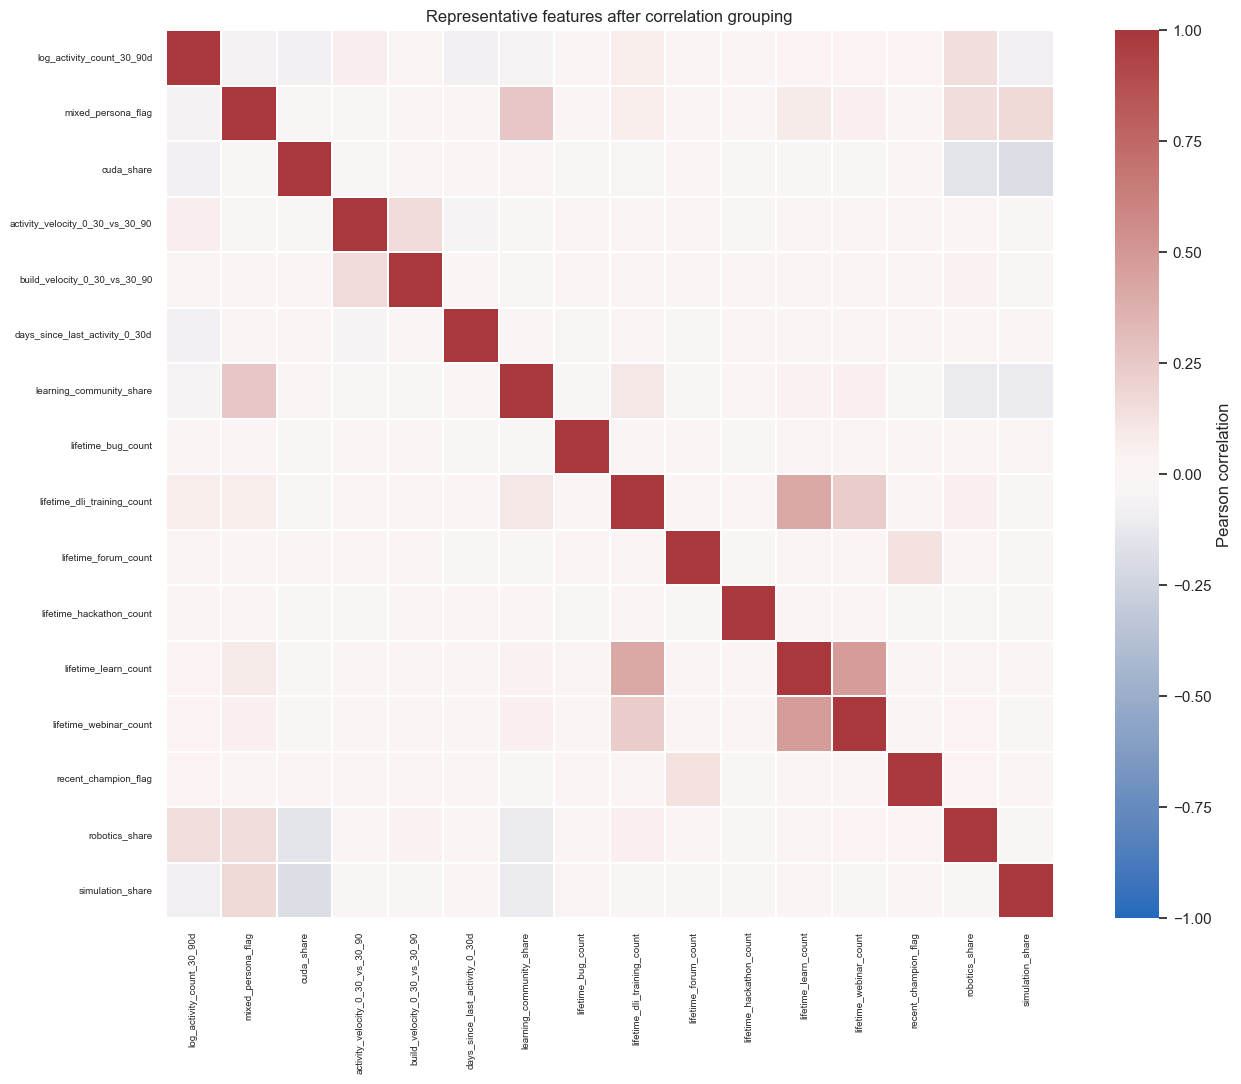

In [7]:
# Build correlation groups and choose one representative feature from each group.
# Self-contained: safe to run after a kernel restart.

from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

DB_PATH = "developer_project.duckdb"
PROFILE_TABLE = "dev_profile_final_v4"
V3_CLUSTER_OUTPUT_DIR = Path("outputs/clustering/v3")
V3_CLUSTER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_N = 100_000
HASH_SALT = 42
CORR_GROUP_THRESHOLD = 0.50
GROUPED_FEATURE_DIR = V3_CLUSTER_OUTPUT_DIR / "feature_selection_grouped"
GROUPED_FEATURE_DIR.mkdir(parents=True, exist_ok=True)

STRATA_ORDER = ["active", "cooling", "dormant"]
STRATA = {
    "active": {
        "label": "Active (recent 30d activity)",
        "where_sql": (
            "is_activated = 1 AND COALESCE(dormancy_status, '') = 'Active' "
            "AND COALESCE(has_activity_0_30d, 0) = 1"
        ),
        "stratify_col": "persona",
        "min_cluster_frac": 0.005,
        "min_samples": 15,
    },
    "cooling": {
        "label": "Cooling",
        "where_sql": "COALESCE(dormancy_status, '') = 'Cooling'",
        "stratify_col": "persona",
        "min_cluster_frac": 0.007,
        "min_samples": 20,
    },
    "dormant": {
        "label": "Dormant",
        "where_sql": "COALESCE(dormancy_status, '') = 'Dormant'",
        "stratify_col": "persona",
        "min_cluster_frac": 0.007,
        "min_samples": 25,
    },
}

EXCLUDE_EXACT = {
    "developer_id",
    "contact_created_date", "contact_first_activity_date", "contact_last_activity_date",
    "account_id", "account_type", "country", "region", "industry_segment_vertical",
    "program_application_source", "organization_english_name", "normalized_account_name",
    "wwfo_category", "wwfo_target_list",
    "behavior_journey_stage_30d", "behavior_journey_rank_30d",
    "current_journey_state_30d", "current_journey_rank_30d",
    "final_lifecycle_status", "persona", "persona_confidence_tier", "developer_effort_level",
    "dormancy_status", "user_type", "max_stage_reached",
    "last_meaningful_week_start", "lifetime_first_activity_date", "lifetime_last_activity_date",
    "missing_contact_metadata_flag",
}
RAW_LIFETIME_SUPERSEDED = {
    "lifetime_activity_count", "lifetime_activity_score_sum", "lifetime_build_count",
    "lifetime_high_effort_count", "lifetime_total_confidence_weighted_effort",
    "lifetime_effort_x_activity_score_sum",
}


def should_exclude(col: str) -> bool:
    if col in EXCLUDE_EXACT or col in RAW_LIFETIME_SUPERSEDED:
        return True
    return col.startswith("first_activity_date") or col.startswith("last_activity_date")


def _sample_stratum(con, stratum_key, where_sql, stratify_col, sample_target, hash_salt):
    view = f"clustering_cohort_v3_{stratum_key}"
    sample_table = f"clustering_sample_v3_{stratum_key}"
    con.execute(f"CREATE OR REPLACE VIEW {view} AS SELECT * FROM {PROFILE_TABLE} WHERE {where_sql}")
    cohort_n = con.execute(f"SELECT COUNT(*) FROM {view}").fetchone()[0]
    target = min(sample_target, cohort_n)
    if cohort_n == 0:
        return 0, 0, sample_table
    if cohort_n <= target:
        con.execute(f"CREATE OR REPLACE TABLE {sample_table} AS SELECT * FROM {view}")
        return cohort_n, cohort_n, sample_table
    con.execute(f"""
        CREATE OR REPLACE TABLE {sample_table} AS
        WITH cohort AS (SELECT * FROM {view}),
        targets AS (
            SELECT {stratify_col}, COUNT(*) AS stratum_n,
                GREATEST(1, CAST(ROUND(COUNT(*) * 1.0 / SUM(COUNT(*)) OVER () * {target}) AS BIGINT)) AS target_n
            FROM cohort GROUP BY {stratify_col}
        ),
        ranked AS (
            SELECT c.*,
                ROW_NUMBER() OVER (PARTITION BY c.{stratify_col} ORDER BY hash(c.developer_id || '{hash_salt}')) AS rn,
                t.target_n
            FROM cohort c JOIN targets t USING ({stratify_col})
        )
        SELECT * EXCLUDE (rn, target_n) FROM ranked WHERE rn <= target_n
    """)
    sample_n = con.execute(f"SELECT COUNT(*) FROM {sample_table}").fetchone()[0]
    if sample_n > target:
        con.execute(f"""
            CREATE OR REPLACE TABLE {sample_table} AS
            SELECT * EXCLUDE (rn) FROM (
                SELECT *, ROW_NUMBER() OVER (ORDER BY hash(developer_id || '{hash_salt}')) AS rn
                FROM {sample_table}
            ) WHERE rn <= {target}
        """)
        sample_n = con.execute(f"SELECT COUNT(*) FROM {sample_table}").fetchone()[0]
    return cohort_n, sample_n, sample_table


def _feature_priority(feature: str) -> int:
    """Higher scores are kept first when correlated features compete."""
    score = 0
    if feature.startswith("log_clipped_"):
        score += 35
    elif feature.startswith("log_"):
        score += 30
    elif feature.startswith("clipped_"):
        score += 25
    if any(token in feature for token in ["share", "ratio", "per_", "velocity", "avg_"]):
        score += 20
    if any(token in feature for token in ["days_since", "has_", "flag", "0_30d", "30_90d", "90_180d"]):
        score += 10
    if feature.startswith("lifetime_"):
        score -= 10
    return score


def _stratified_candidate_feature_frame(con) -> pd.DataFrame:
    profile_cols = [r[0] for r in con.execute(
        "SELECT column_name FROM information_schema.columns "
        f"WHERE table_name = '{PROFILE_TABLE}' ORDER BY ordinal_position"
    ).fetchall()]
    frames = []

    for stratum_key in STRATA_ORDER:
        cfg = STRATA[stratum_key]
        _, _, sample_table = _sample_stratum(
            con,
            stratum_key,
            cfg["where_sql"],
            cfg["stratify_col"],
            SAMPLE_N,
            HASH_SALT,
        )
        df = con.execute(f"SELECT * FROM {sample_table}").fetchdf()
        candidate = [c for c in profile_cols if c in df.columns and not should_exclude(c)]
        numeric_cols = [c for c in candidate if pd.api.types.is_numeric_dtype(df[c])]
        frames.append(df[numeric_cols])

    features = pd.concat(frames, ignore_index=True, sort=False)
    features = features.loc[:, features.notna().any(axis=0)]

    imputer = SimpleImputer(strategy="median")
    feature_df = pd.DataFrame(imputer.fit_transform(features), columns=features.columns)
    return feature_df.loc[:, feature_df.var(axis=0) > 1e-12]


def _correlation_groups(abs_corr: pd.DataFrame, threshold: float) -> list[list[str]]:
    # Union-find connected components over the high-correlation graph.
    parent = {feature: feature for feature in abs_corr.columns}

    def find(feature):
        while parent[feature] != feature:
            parent[feature] = parent[parent[feature]]
            feature = parent[feature]
        return feature

    def union(left, right):
        left_root = find(left)
        right_root = find(right)
        if left_root != right_root:
            parent[right_root] = left_root

    features = list(abs_corr.columns)
    for i, left in enumerate(features):
        for right in features[i + 1:]:
            if abs_corr.loc[left, right] >= threshold:
                union(left, right)

    groups = {}
    for feature in features:
        groups.setdefault(find(feature), []).append(feature)

    return sorted(groups.values(), key=lambda group: (-len(group), sorted(group)[0]))


def _feature_selection_stats(feature_df: pd.DataFrame) -> pd.DataFrame:
    scaled_variance = RobustScaler().fit_transform(feature_df).var(axis=0)
    return pd.DataFrame({
        "feature": feature_df.columns,
        "priority": [_feature_priority(col) for col in feature_df.columns],
        "nonzero_rate": [(feature_df[col] != 0).mean() for col in feature_df.columns],
        "variance": [feature_df[col].var() for col in feature_df.columns],
        "scaled_variance": scaled_variance,
    })


def build_correlation_group_representatives(con, threshold: float = CORR_GROUP_THRESHOLD):
    feature_df = _stratified_candidate_feature_frame(con)
    corr = feature_df.corr()
    abs_corr = corr.abs()
    stats = _feature_selection_stats(feature_df).set_index("feature")
    groups = _correlation_groups(abs_corr, threshold)

    rows = []
    representatives = []

    for idx, group in enumerate(groups, start=1):
        ranked = (
            stats.loc[group]
            .sort_values(
                ["priority", "scaled_variance", "nonzero_rate"],
                ascending=[False, False, False],
            )
        )
        recommended = ranked.index[0]
        representatives.append(recommended)

        group_corr = abs_corr.loc[group, group]
        max_group_corr = (
            group_corr.where(np.triu(np.ones(group_corr.shape), k=1).astype(bool)).max().max()
            if len(group) > 1 else 0.0
        )
        reason = (
            "single feature; no correlated alternatives above threshold"
            if len(group) == 1
            else (
                f"selected highest-priority representative from {len(group)} features linked by "
                f"abs(corr) >= {threshold}; priority={int(stats.loc[recommended, 'priority'])}, "
                f"scaled_variance={stats.loc[recommended, 'scaled_variance']:.3f}"
            )
        )

        rows.append({
            "correlation_group": f"corr_group_{idx:03d}",
            "n_features_in_group": len(group),
            "candidate_features": " | ".join(sorted(group)),
            "recommended_feature": recommended,
            "max_abs_corr_in_group": round(float(max_group_corr), 4),
            "reason": reason,
        })

    group_table = pd.DataFrame(rows)
    selected_corr = corr.loc[representatives, representatives]
    max_selected_abs_corr = (
        selected_corr.abs()
        .where(np.triu(np.ones(selected_corr.shape), k=1).astype(bool))
        .max()
        .max()
    )

    group_table.to_csv(GROUPED_FEATURE_DIR / "v3_correlation_groups_abs_corr_ge_0_50.csv", index=False)
    pd.Series(representatives, name="feature").to_csv(
        GROUPED_FEATURE_DIR / "v3_group_representative_features.csv",
        index=False,
    )
    (GROUPED_FEATURE_DIR / "v3_group_representative_features.txt").write_text(
        "\n".join(representatives) + "\n"
    )
    selected_corr.to_csv(GROUPED_FEATURE_DIR / "v3_group_representative_feature_correlation.csv")

    print(f"Started with {feature_df.shape[1]:,} candidate clustering features")
    print(f"Built {len(group_table):,} correlation groups using abs(corr) >= {threshold}")
    print(f"Selected {len(representatives):,} representative features")
    print(f"Max abs(corr) among representatives: {max_selected_abs_corr:.3f}")
    print(f"Saved group table: {GROUPED_FEATURE_DIR / 'v3_correlation_groups_abs_corr_ge_0_50.csv'}")

    return representatives, group_table, selected_corr


con = duckdb.connect(DB_PATH)
v3_group_representative_features, v3_correlation_group_table, v3_group_representative_corr = (
    build_correlation_group_representatives(con, CORR_GROUP_THRESHOLD)
)
con.close()

display(v3_correlation_group_table)

plt.figure(figsize=(14, 11))
sns.heatmap(
    v3_group_representative_corr,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.1,
    cbar_kws={"label": "Pearson correlation"},
)
plt.title("Representative features after correlation grouping")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

## Rerun HDBSCAN with correlation-group representatives

This repeats the v2/v3 HDBSCAN flow on the same stratified samples, still without SVD, using only the representative feature from each correlation group. Results are written separately under `outputs/clustering/v3_corr_groups/`.

In [8]:
# Rerun HDBSCAN directly on scaled correlation-group representative features.

GROUPED_CLUSTER_OUTPUT_DIR = Path("outputs/clustering/v3_corr_groups")
GROUPED_CLUSTER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GROUPED_FEATURE_LIST_PATH = GROUPED_FEATURE_DIR / "v3_group_representative_features.txt"


def load_group_representative_features() -> list[str]:
    if "v3_group_representative_features" in globals() and v3_group_representative_features:
        return list(v3_group_representative_features)
    if GROUPED_FEATURE_LIST_PATH.exists():
        return [line.strip() for line in GROUPED_FEATURE_LIST_PATH.read_text().splitlines() if line.strip()]
    raise FileNotFoundError(
        f"Missing grouped feature list: {GROUPED_FEATURE_LIST_PATH}. "
        "Run the correlation-group representative cell first."
    )


def run_v3_grouped_stratum(con, stratum_key, selected_features, fit_umap=False):
    cfg = STRATA[stratum_key]
    out_dir = GROUPED_CLUSTER_OUTPUT_DIR / stratum_key
    out_dir.mkdir(parents=True, exist_ok=True)

    cohort_n, sample_n, sample_table = _sample_stratum(
        con, stratum_key, cfg["where_sql"], cfg["stratify_col"], SAMPLE_N, HASH_SALT
    )
    if cohort_n == 0:
        return StratumRunResult(stratum_key, 0, 0, 0, 0, 0.0, 0, out_dir, True, "empty cohort")
    if sample_n < MIN_ROWS:
        return StratumRunResult(stratum_key, cohort_n, sample_n, 0, 0, 0.0, 0, out_dir, True, f"n < {MIN_ROWS}")

    df, X_scaled, feature_names, missing_selected, preprocessor = _build_reduced_feature_matrices(
        con, sample_table, selected_features
    )
    mcs = max(30, int(sample_n * cfg["min_cluster_frac"]))
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=mcs,
        min_samples=cfg["min_samples"],
        metric="euclidean",
        cluster_selection_method="eom",
        core_dist_n_jobs=1,
    )
    labels = clusterer.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = round(100.0 * (labels == -1).sum() / len(labels), 2)

    results = pd.DataFrame({
        "developer_id": df["developer_id"].values,
        "dormancy_segment": stratum_key,
        "hdbscan_cluster": labels,
        "hdbscan_probability": getattr(clusterer, "probabilities_", np.ones(len(labels))),
        "noise_flag": (labels == -1).astype(int),
        "persona": df["persona"].values,
        "dormancy_status": df["dormancy_status"].values,
        "current_journey_state_30d": df["current_journey_state_30d"].values,
        "final_lifecycle_status": df["final_lifecycle_status"].values,
        "behavior_journey_stage_30d": df["behavior_journey_stage_30d"].values,
    })

    if fit_umap:
        emb = umap.UMAP(**UMAP_PARAMS).fit_transform(X_scaled)
        results["umap_x"] = emb[:, 0]
        results["umap_y"] = emb[:, 1]

    summary = build_cluster_summary(df, labels, stratum_key, sample_n)
    results.to_parquet(out_dir / "cluster_results.parquet", index=False)
    summary.to_csv(out_dir / "cluster_summary_table.csv", index=False)
    pd.Series(feature_names, name="feature").to_csv(out_dir / "features_used.csv", index=False)
    joblib.dump(
        {
            "preprocessor": preprocessor,
            "feature_names": feature_names,
            "dropped_selected_features_for_this_stratum": missing_selected,
            "method": "hdbscan_on_correlation_group_representatives_no_svd",
        },
        out_dir / "preprocessor.joblib",
    )

    con.register(f"clusters_v3_corr_groups_{stratum_key}", results)
    con.execute(f"DROP TABLE IF EXISTS developer_clusters_v3_corr_groups_{stratum_key}")
    con.execute(
        f"CREATE TABLE developer_clusters_v3_corr_groups_{stratum_key} "
        f"AS SELECT * FROM clusters_v3_corr_groups_{stratum_key}"
    )
    con.unregister(f"clusters_v3_corr_groups_{stratum_key}")

    return StratumRunResult(stratum_key, cohort_n, sample_n, X_scaled.shape[1], n_clusters, noise_pct, mcs, out_dir)


group_representative_features = load_group_representative_features()
print(f"Loaded {len(group_representative_features):,} grouped representative features")
print(f"Output: {GROUPED_CLUSTER_OUTPUT_DIR.resolve()}")

con = duckdb.connect(DB_PATH)
grouped_run_results = []
grouped_result_frames = []

for key in STRATA_ORDER:
    print(f"\n{'=' * 60}\nStratum: {key} - {STRATA[key]['label']}\n{'=' * 60}")
    res = run_v3_grouped_stratum(con, key, group_representative_features, fit_umap=RUN_UMAP_VIZ)
    grouped_run_results.append({k: v for k, v in res.__dict__.items() if k != "output_dir"})
    print(
        f"  cohort_n={res.cohort_n:,}  sample_n={res.sample_n:,}  "
        f"features={res.n_features}  clusters={res.n_clusters}  noise={res.noise_pct}%"
        + (f"  SKIPPED: {res.skip_reason}" if res.skipped else "")
    )
    if not res.skipped:
        grouped_result_frames.append(pd.read_parquet(res.output_dir / "cluster_results.parquet"))

grouped_run_summary_df = pd.DataFrame(grouped_run_results)
grouped_run_summary_df.to_csv(GROUPED_CLUSTER_OUTPUT_DIR / "run_summary.csv", index=False)
display(grouped_run_summary_df)

if grouped_result_frames:
    grouped_combined_results = pd.concat(grouped_result_frames, ignore_index=True)
    grouped_combined_results.to_parquet(GROUPED_CLUSTER_OUTPUT_DIR / "cluster_results_all.parquet", index=False)

    grouped_summary_parts = [
        pd.read_csv(GROUPED_CLUSTER_OUTPUT_DIR / key / "cluster_summary_table.csv")
        for key in STRATA_ORDER
        if (GROUPED_CLUSTER_OUTPUT_DIR / key / "cluster_summary_table.csv").exists()
    ]
    grouped_summary_all = pd.concat(grouped_summary_parts, ignore_index=True)
    grouped_summary_all.to_csv(GROUPED_CLUSTER_OUTPUT_DIR / "cluster_summary_table_all.csv", index=False)

    con.register("developer_clusters_v3_corr_groups_df", grouped_combined_results)
    con.execute("DROP TABLE IF EXISTS developer_clusters_v3_corr_groups")
    con.execute("CREATE TABLE developer_clusters_v3_corr_groups AS SELECT * FROM developer_clusters_v3_corr_groups_df")
    con.unregister("developer_clusters_v3_corr_groups_df")

    print(f"Combined: {len(grouped_combined_results):,} developers with cluster labels")
    print("DuckDB table: developer_clusters_v3_corr_groups")
else:
    print("No strata completed.")

con.close()

Loaded 16 grouped representative features
Output: /Users/pmazolew/Documents/GitHub/Spring2026_IndustryProject/outputs/clustering/v3_corr_groups

Stratum: active - Active (recent 30d activity)
  cohort_n=418,049  sample_n=99,999  features=16  clusters=47  noise=8.36%

Stratum: cooling - Cooling
  cohort_n=356,500  sample_n=100,000  features=12  clusters=28  noise=14.42%

Stratum: dormant - Dormant
  cohort_n=5,304,852  sample_n=100,000  features=11  clusters=33  noise=28.26%


,stratum_key,cohort_n,sample_n,n_features,n_clusters,noise_pct,min_cluster_size,skipped,skip_reason
0,active,418049,99999,16,47,8.36,499,False,
1,cooling,356500,100000,12,28,14.42,700,False,
2,dormant,5304852,100000,11,33,28.26,700,False,


Combined: 299,999 developers with cluster labels
DuckDB table: developer_clusters_v3_corr_groups


## V3 correlation-group clustering by dormancy and persona

This fits HDBSCAN separately for each `(dormancy_segment, persona_group)` cohort using the correlation-group representative features. Persona groups are `CUDA`, `GenAI`, `Robotics`, `Simulation`, `Learning_Community`, and `Unknown_or_Other`.

In [1]:
# Self-contained dormancy x persona HDBSCAN run.
# Uses saved correlation-group representative features and writes outputs to:
# outputs/clustering/v3_corr_groups_by_persona/

import warnings
from dataclasses import dataclass
from pathlib import Path

import duckdb
import hdbscan
import joblib
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore", category=FutureWarning)

DB_PATH = "developer_project.duckdb"
PROFILE_TABLE = "dev_profile_final_v4"
OUTPUT_DIR = Path("outputs/clustering/v3_corr_groups_by_persona")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GROUPED_FEATURE_LIST_PATH = Path("outputs/clustering/v3/feature_selection_grouped/v3_group_representative_features.txt")
PERSONA_SAMPLE_N = 100_000
RANDOM_STATE = 42
HASH_SALT = 42
MIN_ROWS = 200

PERSONA_GROUPS = [
    "CUDA",
    "GenAI",
    "Robotics",
    "Simulation",
    "Learning_Community",
    "Unknown_or_Other",
]
KNOWN_PERSONAS_SQL = "'CUDA', 'GenAI', 'Robotics', 'Simulation', 'Learning_Community'"
STRATA_ORDER = ["active", "cooling", "dormant"]

EXCLUDE_EXACT = {
    "developer_id",
    "contact_created_date", "contact_first_activity_date", "contact_last_activity_date",
    "account_id", "account_type", "country", "region", "industry_segment_vertical",
    "program_application_source", "organization_english_name", "normalized_account_name",
    "wwfo_category", "wwfo_target_list",
    "behavior_journey_stage_30d", "behavior_journey_rank_30d",
    "current_journey_state_30d", "current_journey_rank_30d",
    "final_lifecycle_status", "persona", "persona_confidence_tier", "developer_effort_level",
    "dormancy_status", "user_type", "max_stage_reached",
    "last_meaningful_week_start", "lifetime_first_activity_date", "lifetime_last_activity_date",
    "missing_contact_metadata_flag",
}
RAW_LIFETIME_SUPERSEDED = {
    "lifetime_activity_count", "lifetime_activity_score_sum", "lifetime_build_count",
    "lifetime_high_effort_count", "lifetime_total_confidence_weighted_effort",
    "lifetime_effort_x_activity_score_sum",
}
PROFILE_COLS = [
    "activity_count_0_30d", "log_activity_count_0_30d", "log_activity_count_30_90d",
    "build_count_0_30d", "log_build_count_0_30d", "log_build_count_30_90d",
    "lifetime_learn_count", "lifetime_build_count", "lifetime_champion_count",
    "lifetime_discover_count", "developer_effort_score", "days_since_last_activity",
    "cuda_share", "genai_share", "robotics_share", "simulation_share",
]
STRATA = {
    "active": {
        "label": "Active (recent 30d activity)",
        "where_sql": (
            "is_activated = 1 AND COALESCE(dormancy_status, '') = 'Active' "
            "AND COALESCE(has_activity_0_30d, 0) = 1"
        ),
        "min_cluster_frac": 0.005,
        "min_samples": 15,
    },
    "cooling": {
        "label": "Cooling",
        "where_sql": "COALESCE(dormancy_status, '') = 'Cooling'",
        "min_cluster_frac": 0.007,
        "min_samples": 20,
    },
    "dormant": {
        "label": "Dormant",
        "where_sql": "COALESCE(dormancy_status, '') = 'Dormant'",
        "min_cluster_frac": 0.007,
        "min_samples": 25,
    },
}


def should_exclude(col: str) -> bool:
    if col in EXCLUDE_EXACT or col in RAW_LIFETIME_SUPERSEDED:
        return True
    return col.startswith("first_activity_date") or col.startswith("last_activity_date")


def load_group_representative_features() -> list[str]:
    if not GROUPED_FEATURE_LIST_PATH.exists():
        raise FileNotFoundError(
            f"Missing grouped feature list: {GROUPED_FEATURE_LIST_PATH}. "
            "Run the correlation-group representative feature cell first."
        )
    return [line.strip() for line in GROUPED_FEATURE_LIST_PATH.read_text().splitlines() if line.strip()]


def persona_slug(persona_group: str) -> str:
    return persona_group.lower().replace(" ", "_").replace("/", "_")


def persona_where_sql(persona_group: str) -> str:
    if persona_group == "Unknown_or_Other":
        return f"(persona IS NULL OR persona NOT IN ({KNOWN_PERSONAS_SQL}))"
    return f"persona = '{persona_group}'"


@dataclass
class CohortRunResult:
    cohort_key: str
    dormancy_segment: str
    persona_group: str
    cohort_n: int
    sample_n: int
    n_features: int
    n_clusters: int
    noise_pct: float
    min_cluster_size: int
    skipped: bool = False
    skip_reason: str = ""


def sample_persona_cohort(con, dormancy_key, persona_group):
    cfg = STRATA[dormancy_key]
    cohort_key = f"{dormancy_key}_{persona_slug(persona_group)}"
    view = f"clustering_cohort_v3_persona_{cohort_key}"
    sample_table = f"clustering_sample_v3_persona_{cohort_key}"
    where_sql = f"({cfg['where_sql']}) AND ({persona_where_sql(persona_group)})"

    con.execute(f"CREATE OR REPLACE VIEW {view} AS SELECT * FROM {PROFILE_TABLE} WHERE {where_sql}")
    cohort_n = con.execute(f"SELECT COUNT(*) FROM {view}").fetchone()[0]
    target = min(PERSONA_SAMPLE_N, cohort_n)

    if cohort_n == 0:
        return cohort_key, 0, 0, sample_table
    if cohort_n <= target:
        con.execute(f"CREATE OR REPLACE TABLE {sample_table} AS SELECT * FROM {view}")
        return cohort_key, cohort_n, cohort_n, sample_table

    con.execute(f"""
        CREATE OR REPLACE TABLE {sample_table} AS
        SELECT * EXCLUDE (rn) FROM (
            SELECT *, ROW_NUMBER() OVER (ORDER BY hash(developer_id || '{HASH_SALT}')) AS rn
            FROM {view}
        )
        WHERE rn <= {target}
    """)
    sample_n = con.execute(f"SELECT COUNT(*) FROM {sample_table}").fetchone()[0]
    return cohort_key, cohort_n, sample_n, sample_table


def build_feature_matrix(con, sample_table, selected_features):
    profile_cols = [r[0] for r in con.execute(
        "SELECT column_name FROM information_schema.columns "
        f"WHERE table_name = '{PROFILE_TABLE}' ORDER BY ordinal_position"
    ).fetchall()]
    sample_cols = [r[0] for r in con.execute(
        "SELECT column_name FROM information_schema.columns "
        f"WHERE table_name = '{sample_table}' ORDER BY ordinal_position"
    ).fetchall()]

    selected_set = set(selected_features)
    candidate = [c for c in profile_cols if c in sample_cols and c in selected_set and not should_exclude(c)]
    df = con.execute(f"SELECT * FROM {sample_table}").fetchdf()
    numeric_cols = [c for c in candidate if pd.api.types.is_numeric_dtype(df[c]) and df[c].notna().any()]

    if not numeric_cols:
        raise ValueError(f"No usable selected numeric features found for {sample_table}")

    preprocessor = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ])
    X_scaled = preprocessor.fit_transform(df[numeric_cols])
    keep = np.var(X_scaled, axis=0) > 1e-12
    feature_names = [numeric_cols[i] for i, keep_col in enumerate(keep) if keep_col]
    X_scaled = X_scaled[:, keep]

    if X_scaled.shape[1] == 0:
        raise ValueError(f"All selected features were zero-variance for {sample_table}")

    missing_selected = [c for c in selected_features if c not in feature_names]
    return df, X_scaled, feature_names, missing_selected, preprocessor


def behavioral_segment_name(g, dormancy_key):
    def m(col):
        return float(g[col].mean()) if col in g.columns and g[col].notna().any() else 0.0

    learn = m("lifetime_learn_count") + m("log_activity_count_0_30d")
    build = m("lifetime_build_count") + m("build_count_0_30d") + m("log_build_count_0_30d")
    champ = m("lifetime_champion_count")
    discover = m("lifetime_discover_count")
    recent = m("activity_count_0_30d")

    if build >= max(learn, champ, discover, 1e-9) and build > 0:
        base = "Builders"
    elif champ >= max(learn, build, discover, 1e-9) and champ > 0:
        base = "Champions"
    elif learn >= max(build, champ, discover, 1e-9) and learn > 0:
        base = "Learners"
    elif discover >= max(learn, build, champ, 1e-9) and discover > 0:
        base = "Explorers"
    elif recent > 0:
        base = "Active_Mixed"
    else:
        base = "Low_Signal"

    if dormancy_key == "dormant" and build > learn and build > 0:
        return f"Dormant_Former_{base}"
    if dormancy_key == "cooling":
        return f"Cooling_{base}"
    return base


def build_cluster_summary(df, labels, dormancy_key, persona_group, cohort_key, sample_n):
    tmp = df.copy()
    tmp["hdbscan_cluster"] = labels
    rows = []
    profile_cols = [c for c in PROFILE_COLS if c in tmp.columns]

    for cid, g in tmp.groupby("hdbscan_cluster", observed=True):
        row = {
            "cohort_key": cohort_key,
            "dormancy_segment": dormancy_key,
            "persona_group": persona_group,
            "hdbscan_cluster": int(cid),
            "n": len(g),
            "pct_of_sample": round(100.0 * len(g) / sample_n, 2),
            "noise_flag": int(cid == -1),
        }
        if cid >= 0 and len(g):
            row["top_persona"] = g["persona"].value_counts().index[0]
            row["top_persona_pct"] = round(100.0 * g["persona"].value_counts().iloc[0] / len(g), 2)
            row["top_journey_state_30d"] = g["current_journey_state_30d"].mode().iloc[0] if g["current_journey_state_30d"].notna().any() else ""
            row["top_lifecycle_status"] = g["final_lifecycle_status"].mode().iloc[0] if g["final_lifecycle_status"].notna().any() else ""
            row["top_dormancy_status"] = g["dormancy_status"].mode().iloc[0] if g["dormancy_status"].notna().any() else ""
            row["behavioral_segment_name"] = behavioral_segment_name(g, dormancy_key)
        else:
            row.update({
                "top_persona": "",
                "top_persona_pct": 0.0,
                "top_journey_state_30d": "",
                "top_lifecycle_status": "",
                "top_dormancy_status": "",
                "behavioral_segment_name": "Unclustered_Noise",
            })
        for col in profile_cols:
            val = g[col].mean()
            row[f"mean_{col}"] = None if pd.isna(val) else float(val)
        rows.append(row)

    return pd.DataFrame(rows).sort_values(["cohort_key", "noise_flag", "n"], ascending=[True, True, False])


def run_persona_cohort(con, dormancy_key, persona_group, selected_features):
    cfg = STRATA[dormancy_key]
    cohort_key, cohort_n, sample_n, sample_table = sample_persona_cohort(con, dormancy_key, persona_group)
    out_dir = OUTPUT_DIR / cohort_key
    out_dir.mkdir(parents=True, exist_ok=True)

    if cohort_n == 0:
        return CohortRunResult(cohort_key, dormancy_key, persona_group, 0, 0, 0, 0, 0.0, 0, True, "empty cohort"), None
    if sample_n < MIN_ROWS:
        return CohortRunResult(cohort_key, dormancy_key, persona_group, cohort_n, sample_n, 0, 0, 0.0, 0, True, f"n < {MIN_ROWS}"), None

    df, X_scaled, feature_names, missing_selected, preprocessor = build_feature_matrix(con, sample_table, selected_features)
    min_cluster_size = max(30, int(sample_n * cfg["min_cluster_frac"]))
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=cfg["min_samples"],
        metric="euclidean",
        cluster_selection_method="eom",
        core_dist_n_jobs=1,
    )
    labels = clusterer.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_pct = round(100.0 * (labels == -1).sum() / len(labels), 2)

    results = pd.DataFrame({
        "developer_id": df["developer_id"].values,
        "cohort_key": cohort_key,
        "dormancy_segment": dormancy_key,
        "persona_group": persona_group,
        "hdbscan_cluster": labels,
        "hdbscan_probability": getattr(clusterer, "probabilities_", np.ones(len(labels))),
        "noise_flag": (labels == -1).astype(int),
        "persona": df["persona"].values,
        "dormancy_status": df["dormancy_status"].values,
        "current_journey_state_30d": df["current_journey_state_30d"].values,
        "final_lifecycle_status": df["final_lifecycle_status"].values,
        "behavior_journey_stage_30d": df["behavior_journey_stage_30d"].values,
    })
    summary = build_cluster_summary(df, labels, dormancy_key, persona_group, cohort_key, sample_n)

    results.to_parquet(out_dir / "cluster_results.parquet", index=False)
    summary.to_csv(out_dir / "cluster_summary_table.csv", index=False)
    pd.Series(feature_names, name="feature").to_csv(out_dir / "features_used.csv", index=False)
    joblib.dump(
        {
            "preprocessor": preprocessor,
            "feature_names": feature_names,
            "dropped_selected_features_for_this_cohort": missing_selected,
            "method": "hdbscan_by_dormancy_persona_on_correlation_group_representatives_no_svd",
        },
        out_dir / "preprocessor.joblib",
    )

    run_result = CohortRunResult(
        cohort_key,
        dormancy_key,
        persona_group,
        cohort_n,
        sample_n,
        X_scaled.shape[1],
        n_clusters,
        noise_pct,
        min_cluster_size,
    )
    return run_result, results


selected_features = load_group_representative_features()
print(f"Loaded {len(selected_features):,} grouped representative features")
print(f"Output: {OUTPUT_DIR.resolve()}")

con = duckdb.connect(DB_PATH)
run_rows = []
result_frames = []

for dormancy_key in STRATA_ORDER:
    for persona_group in PERSONA_GROUPS:
        print(f"\n{'=' * 72}\nCohort: {dormancy_key} / {persona_group}\n{'=' * 72}", flush=True)
        run_result, results = run_persona_cohort(con, dormancy_key, persona_group, selected_features)
        run_rows.append(run_result.__dict__)
        print(
            f"  cohort_n={run_result.cohort_n:,}  sample_n={run_result.sample_n:,}  "
            f"features={run_result.n_features}  clusters={run_result.n_clusters}  noise={run_result.noise_pct}%"
            + (f"  SKIPPED: {run_result.skip_reason}" if run_result.skipped else ""),
            flush=True,
        )
        if results is not None:
            result_frames.append(results)

run_summary_df = pd.DataFrame(run_rows)
run_summary_df.to_csv(OUTPUT_DIR / "run_summary.csv", index=False)
display(run_summary_df)

if result_frames:
    combined_results = pd.concat(result_frames, ignore_index=True)
    combined_results.to_parquet(OUTPUT_DIR / "cluster_results_all.parquet", index=False)

    summary_parts = [
        pd.read_csv(OUTPUT_DIR / f"{dormancy_key}_{persona_slug(persona_group)}" / "cluster_summary_table.csv")
        for dormancy_key in STRATA_ORDER
        for persona_group in PERSONA_GROUPS
        if (OUTPUT_DIR / f"{dormancy_key}_{persona_slug(persona_group)}" / "cluster_summary_table.csv").exists()
    ]
    cluster_summary_all = pd.concat(summary_parts, ignore_index=True)
    cluster_summary_all.to_csv(OUTPUT_DIR / "cluster_summary_table_all.csv", index=False)

    con.register("developer_clusters_v3_corr_groups_by_persona_df", combined_results)
    con.execute("DROP TABLE IF EXISTS developer_clusters_v3_corr_groups_by_persona")
    con.execute(
        "CREATE TABLE developer_clusters_v3_corr_groups_by_persona "
        "AS SELECT * FROM developer_clusters_v3_corr_groups_by_persona_df"
    )
    con.unregister("developer_clusters_v3_corr_groups_by_persona_df")

    print(f"Combined: {len(combined_results):,} developers with cluster labels")
    print("DuckDB table: developer_clusters_v3_corr_groups_by_persona")
    display(cluster_summary_all)
else:
    print("No persona cohorts completed.")

con.close()

Loaded 16 grouped representative features
Output: /Users/pmazolew/Documents/GitHub/Spring2026_IndustryProject/outputs/clustering/v3_corr_groups_by_persona

Cohort: active / CUDA
  cohort_n=58,072  sample_n=58,072  features=16  clusters=50  noise=21.55%

Cohort: active / GenAI
  cohort_n=292,033  sample_n=100,000  features=15  clusters=39  noise=7.12%

Cohort: active / Robotics
  cohort_n=25,363  sample_n=25,363  features=16  clusters=29  noise=46.36%

Cohort: active / Simulation
  cohort_n=8,045  sample_n=8,045  features=16  clusters=41  noise=22.5%

Cohort: active / Learning_Community
  cohort_n=10,873  sample_n=10,873  features=16  clusters=60  noise=26.66%

Cohort: active / Unknown_or_Other
  cohort_n=23,663  sample_n=23,663  features=10  clusters=33  noise=1.41%

Cohort: cooling / CUDA
  cohort_n=101,715  sample_n=100,000  features=12  clusters=27  noise=17.65%

Cohort: cooling / GenAI
  cohort_n=154,741  sample_n=100,000  features=12  clusters=24  noise=6.45%

Cohort: cooling / Ro

,cohort_key,dormancy_segment,persona_group,cohort_n,sample_n,n_features,n_clusters,noise_pct,min_cluster_size,skipped,skip_reason
0,active_cuda,active,CUDA,58072,58072,16,50,21.55,290,False,
1,active_genai,active,GenAI,292033,100000,15,39,7.12,500,False,
2,active_robotics,active,Robotics,25363,25363,16,29,46.36,126,False,
3,active_simulation,active,Simulation,8045,8045,16,41,22.50,40,False,
4,active_learning_community,active,Learning_Community,10873,10873,16,60,26.66,54,False,
5,active_unknown_or_other,active,Unknown_or_Other,23663,23663,10,33,1.41,118,False,
6,cooling_cuda,cooling,CUDA,101715,100000,12,27,17.65,700,False,
7,cooling_genai,cooling,GenAI,154741,100000,12,24,6.45,700,False,
8,cooling_robotics,cooling,Robotics,33512,33512,12,22,55.92,234,False,
9,cooling_simulation,cooling,Simulation,11363,11363,11,14,19.80,79,False,


Combined: 1,126,060 developers with cluster labels
DuckDB table: developer_clusters_v3_corr_groups_by_persona


,cohort_key,dormancy_segment,persona_group,hdbscan_cluster,n,pct_of_sample,noise_flag,top_persona,top_persona_pct,top_journey_state_30d,...,mean_lifetime_learn_count,mean_lifetime_build_count,mean_lifetime_champion_count,mean_lifetime_discover_count,mean_developer_effort_score,mean_days_since_last_activity,mean_cuda_share,mean_genai_share,mean_robotics_share,mean_simulation_share
0,active_cuda,active,CUDA,7,6790,11.69,0,CUDA,100.0,Builder,...,0.000000,4.587629,0.000442,2.737997,2.063066,12.111782,0.462755,0.180875,0.026060,0.021940
1,active_cuda,active,CUDA,10,6348,10.93,0,CUDA,100.0,Builder,...,0.000000,3.488973,0.000000,2.357435,1.970573,10.779616,0.697808,0.074117,0.002369,0.002365
2,active_cuda,active,CUDA,6,3850,6.63,0,CUDA,100.0,Learner,...,0.000000,17.484675,0.074545,14.664675,1.943526,11.753506,0.807083,0.108839,0.010582,0.009129
3,active_cuda,active,CUDA,3,2746,4.73,0,CUDA,100.0,Evaluator,...,1.000000,1.017480,0.000000,1.408230,1.986220,15.420976,0.916208,0.034435,0.017431,0.017071
4,active_cuda,active,CUDA,5,1632,2.81,0,CUDA,100.0,Learner,...,0.000000,10.052083,0.058211,8.975490,2.464261,13.025735,0.461242,0.213181,0.022278,0.016016
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
509,dormant_unknown_or_other,dormant,Unknown_or_Other,1,89916,89.92,0,Unknown,100.0,Dormant_Historically_Active,...,0.000000,0.501646,0.004916,1.196517,0.278221,1014.105165,0.000000,0.000000,0.000000,0.000000
510,dormant_unknown_or_other,dormant,Unknown_or_Other,3,3771,3.77,0,Unknown,100.0,Dormant_Historically_Active,...,1.133121,0.078229,0.000265,0.326704,0.339766,1239.881729,0.000000,0.000000,0.000000,0.000000
511,dormant_unknown_or_other,dormant,Unknown_or_Other,0,3370,3.37,0,Unknown,100.0,Dormant_Historically_Active,...,1.085163,0.016024,0.000000,0.056677,0.315654,1161.934718,0.000000,0.000000,0.000000,0.000000
512,dormant_unknown_or_other,dormant,Unknown_or_Other,2,2422,2.42,0,Unknown,100.0,Dormant_Historically_Active,...,1.162675,0.090008,0.001239,0.874071,0.452927,921.010735,0.000000,0.000000,0.000000,0.000000


## Cluster comparison and quality summaries

These cells compare the two v3 clustering approaches:

- **Dormancy-only:** `outputs/clustering/v3_corr_groups/`
- **Dormancy x persona:** `outputs/clustering/v3_corr_groups_by_persona/`

They summarize cluster counts, weighted noise rates, and near-duplicate cluster pairs within each cohort.

In [9]:
# Load cluster outputs for both v3 clustering approaches.

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.preprocessing import RobustScaler

DORMANCY_ONLY_DIR = Path("outputs/clustering/v3_corr_groups")
DORMANCY_PERSONA_DIR = Path("outputs/clustering/v3_corr_groups_by_persona")


def _read_csv_if_exists(path: Path, label: str) -> pd.DataFrame | None:
    if not path.exists():
        print(f"Missing {label}: {path}")
        return None
    return pd.read_csv(path)


def load_cluster_outputs(output_dir: Path, method_name: str):
    run_summary = _read_csv_if_exists(output_dir / "run_summary.csv", f"{method_name} run summary")
    cluster_summary = _read_csv_if_exists(output_dir / "cluster_summary_table_all.csv", f"{method_name} cluster summary")

    if run_summary is not None:
        run_summary = run_summary.copy()
        run_summary["method"] = method_name
    if cluster_summary is not None:
        cluster_summary = cluster_summary.copy()
        cluster_summary["method"] = method_name

    return run_summary, cluster_summary


dormancy_run_summary, dormancy_cluster_summary = load_cluster_outputs(
    DORMANCY_ONLY_DIR,
    "dormancy_only",
)
persona_run_summary, persona_cluster_summary = load_cluster_outputs(
    DORMANCY_PERSONA_DIR,
    "dormancy_x_persona",
)

print("Loaded outputs:")
print(f"  dormancy_only run rows: {0 if dormancy_run_summary is None else len(dormancy_run_summary):,}")
print(f"  dormancy_only cluster rows: {0 if dormancy_cluster_summary is None else len(dormancy_cluster_summary):,}")
print(f"  dormancy_x_persona run rows: {0 if persona_run_summary is None else len(persona_run_summary):,}")
print(f"  dormancy_x_persona cluster rows: {0 if persona_cluster_summary is None else len(persona_cluster_summary):,}")

Loaded outputs:
  dormancy_only run rows: 3
  dormancy_only cluster rows: 111
  dormancy_x_persona run rows: 18
  dormancy_x_persona cluster rows: 514


In [10]:
# Cluster counts and noise summaries.
# Cluster totals exclude HDBSCAN noise (`hdbscan_cluster == -1`) by default.


def _normalize_run_summary(run_summary: pd.DataFrame | None, method_name: str) -> pd.DataFrame:
    if run_summary is None or run_summary.empty:
        return pd.DataFrame()

    df = run_summary.copy()
    if "stratum_key" in df.columns and "dormancy_segment" not in df.columns:
        df = df.rename(columns={"stratum_key": "cohort_key"})
    if "cohort_key" not in df.columns:
        df["cohort_key"] = df.get("dormancy_segment", "unknown")
    if "dormancy_segment" not in df.columns:
        df["dormancy_segment"] = df["cohort_key"].astype(str).str.split("_").str[0]
    if "persona_group" not in df.columns:
        df["persona_group"] = "all_personas"

    df["method"] = method_name
    df["n_noise_developers"] = (df["sample_n"] * df["noise_pct"] / 100.0).round().astype(int)
    df["n_clustered_developers"] = df["sample_n"] - df["n_noise_developers"]
    df["clusters_excluding_noise"] = df["n_clusters"]
    df["clusters_including_noise_bucket"] = df["n_clusters"] + (df["noise_pct"] > 0).astype(int)
    return df[
        [
            "method",
            "cohort_key",
            "dormancy_segment",
            "persona_group",
            "cohort_n",
            "sample_n",
            "clusters_excluding_noise",
            "clusters_including_noise_bucket",
            "n_clustered_developers",
            "n_noise_developers",
            "noise_pct",
            "min_cluster_size",
        ]
    ]


run_tables = [
    _normalize_run_summary(dormancy_run_summary, "dormancy_only"),
    _normalize_run_summary(persona_run_summary, "dormancy_x_persona"),
]
cluster_count_by_cohort = pd.concat([t for t in run_tables if not t.empty], ignore_index=True)

print("Cluster counts by cohort")
display(cluster_count_by_cohort)

cluster_count_by_dormancy = (
    cluster_count_by_cohort
    .groupby(["method", "dormancy_segment"], as_index=False)
    .agg(
        cohorts=("cohort_key", "nunique"),
        cohort_population=("cohort_n", "sum"),
        sampled_developers=("sample_n", "sum"),
        total_clusters_excluding_noise=("clusters_excluding_noise", "sum"),
        total_clusters_including_noise_buckets=("clusters_including_noise_bucket", "sum"),
        clustered_developers=("n_clustered_developers", "sum"),
        noise_developers=("n_noise_developers", "sum"),
    )
)
cluster_count_by_dormancy["weighted_noise_pct"] = (
    100.0 * cluster_count_by_dormancy["noise_developers"] / cluster_count_by_dormancy["sampled_developers"]
).round(2)

whole_sample_totals = (
    cluster_count_by_cohort
    .groupby("method", as_index=False)
    .agg(
        cohorts=("cohort_key", "nunique"),
        cohort_population=("cohort_n", "sum"),
        sampled_developers=("sample_n", "sum"),
        total_clusters_excluding_noise=("clusters_excluding_noise", "sum"),
        total_clusters_including_noise_buckets=("clusters_including_noise_bucket", "sum"),
        clustered_developers=("n_clustered_developers", "sum"),
        noise_developers=("n_noise_developers", "sum"),
    )
)
whole_sample_totals["dormancy_segment"] = "ALL"
whole_sample_totals["weighted_noise_pct"] = (
    100.0 * whole_sample_totals["noise_developers"] / whole_sample_totals["sampled_developers"]
).round(2)

cluster_count_totals = pd.concat(
    [cluster_count_by_dormancy, whole_sample_totals[cluster_count_by_dormancy.columns]],
    ignore_index=True,
).sort_values(["method", "dormancy_segment"])

print("Cluster totals by dormancy and whole sample")
display(cluster_count_totals)

noise_by_dormancy = (
    cluster_count_by_cohort
    .groupby(["method", "dormancy_segment"], as_index=False)
    .agg(
        cohorts=("cohort_key", "nunique"),
        sampled_developers=("sample_n", "sum"),
        noise_developers=("n_noise_developers", "sum"),
        simple_avg_noise_pct=("noise_pct", "mean"),
    )
)
noise_by_dormancy["weighted_avg_noise_pct"] = (
    100.0 * noise_by_dormancy["noise_developers"] / noise_by_dormancy["sampled_developers"]
).round(2)
noise_by_dormancy["simple_avg_noise_pct"] = noise_by_dormancy["simple_avg_noise_pct"].round(2)

noise_total = (
    cluster_count_by_cohort
    .groupby("method", as_index=False)
    .agg(
        cohorts=("cohort_key", "nunique"),
        sampled_developers=("sample_n", "sum"),
        noise_developers=("n_noise_developers", "sum"),
        simple_avg_noise_pct=("noise_pct", "mean"),
    )
)
noise_total["dormancy_segment"] = "ALL"
noise_total["weighted_avg_noise_pct"] = (
    100.0 * noise_total["noise_developers"] / noise_total["sampled_developers"]
).round(2)
noise_total["simple_avg_noise_pct"] = noise_total["simple_avg_noise_pct"].round(2)

noise_summary = pd.concat(
    [noise_by_dormancy, noise_total[noise_by_dormancy.columns]],
    ignore_index=True,
).sort_values(["method", "dormancy_segment"])

print("Noise summary by dormancy and total")
display(noise_summary)

Cluster counts by cohort


,method,cohort_key,dormancy_segment,persona_group,cohort_n,sample_n,clusters_excluding_noise,clusters_including_noise_bucket,n_clustered_developers,n_noise_developers,noise_pct,min_cluster_size
0,dormancy_only,active,active,all_personas,418049,99999,47,48,91639,8360,8.36,499
1,dormancy_only,cooling,cooling,all_personas,356500,100000,28,29,85580,14420,14.42,700
2,dormancy_only,dormant,dormant,all_personas,5304852,100000,33,34,71740,28260,28.26,700
3,dormancy_x_persona,active_cuda,active,CUDA,58072,58072,50,51,45557,12515,21.55,290
4,dormancy_x_persona,active_genai,active,GenAI,292033,100000,39,40,92880,7120,7.12,500
5,dormancy_x_persona,active_robotics,active,Robotics,25363,25363,29,30,13605,11758,46.36,126
6,dormancy_x_persona,active_simulation,active,Simulation,8045,8045,41,42,6235,1810,22.50,40
7,dormancy_x_persona,active_learning_community,active,Learning_Community,10873,10873,60,61,7974,2899,26.66,54
8,dormancy_x_persona,active_unknown_or_other,active,Unknown_or_Other,23663,23663,33,34,23329,334,1.41,118
9,dormancy_x_persona,cooling_cuda,cooling,CUDA,101715,100000,27,28,82350,17650,17.65,700


Cluster totals by dormancy and whole sample


,method,dormancy_segment,cohorts,cohort_population,sampled_developers,total_clusters_excluding_noise,total_clusters_including_noise_buckets,clustered_developers,noise_developers,weighted_noise_pct
6,dormancy_only,ALL,3,6079401,299999,108,111,248959,51040,17.01
0,dormancy_only,active,1,418049,99999,47,48,91639,8360,8.36
1,dormancy_only,cooling,1,356500,100000,28,29,85580,14420,14.42
2,dormancy_only,dormant,1,5304852,100000,33,34,71740,28260,28.26
7,dormancy_x_persona,ALL,18,6079401,1126060,496,514,947175,178885,15.89
3,dormancy_x_persona,active,6,418049,226016,252,258,189580,36436,16.12
4,dormancy_x_persona,cooling,6,356500,300044,123,129,249805,50239,16.74
5,dormancy_x_persona,dormant,6,5304852,600000,121,127,507790,92210,15.37


Noise summary by dormancy and total


,method,dormancy_segment,cohorts,sampled_developers,noise_developers,simple_avg_noise_pct,weighted_avg_noise_pct
6,dormancy_only,ALL,3,299999,51040,17.01,17.01
0,dormancy_only,active,1,99999,8360,8.36,8.36
1,dormancy_only,cooling,1,100000,14420,14.42,14.42
2,dormancy_only,dormant,1,100000,28260,28.26,28.26
7,dormancy_x_persona,ALL,18,1126060,178885,18.76,15.89
3,dormancy_x_persona,active,6,226016,36436,20.93,16.12
4,dormancy_x_persona,cooling,6,300044,50239,19.97,16.74
5,dormancy_x_persona,dormant,6,600000,92210,15.37,15.37


In [11]:
# Find near-duplicate clusters within each clustering cohort.
# This compares cluster summary mean_* profiles, excluding the HDBSCAN noise bucket.

TOP_N_SIMILAR_PAIRS_PER_COHORT = 15
NEAR_DUPLICATE_COSINE_THRESHOLD = 0.98


def cluster_similarity_pairs(
    cluster_summary: pd.DataFrame | None,
    method_name: str,
    cohort_cols: list[str],
    top_n_per_cohort: int = TOP_N_SIMILAR_PAIRS_PER_COHORT,
) -> pd.DataFrame:
    if cluster_summary is None or cluster_summary.empty:
        return pd.DataFrame()

    df = cluster_summary.copy()
    if "noise_flag" in df.columns:
        df = df[df["noise_flag"] == 0].copy()
    elif "hdbscan_cluster" in df.columns:
        df = df[df["hdbscan_cluster"] != -1].copy()

    mean_cols = [col for col in df.columns if col.startswith("mean_")]
    if not mean_cols:
        raise ValueError(f"No mean_* columns found for {method_name}")

    rows = []
    for cohort_values, cohort_df in df.groupby(cohort_cols, dropna=False):
        if not isinstance(cohort_values, tuple):
            cohort_values = (cohort_values,)
        cohort_label = " / ".join(str(v) for v in cohort_values)
        if len(cohort_df) < 2:
            continue

        X = cohort_df[mean_cols].apply(pd.to_numeric, errors="coerce")
        X = X.dropna(axis=1, how="all")
        X = X.loc[:, X.nunique(dropna=True) > 1]
        if X.shape[1] == 0:
            continue

        X = X.fillna(X.median()).fillna(0)
        X_scaled = RobustScaler().fit_transform(X)
        cosine = cosine_similarity(X_scaled)
        distances = euclidean_distances(X_scaled)

        records = cohort_df.reset_index(drop=True)
        pair_rows = []
        for i in range(len(records)):
            for j in range(i + 1, len(records)):
                row = {
                    "method": method_name,
                    "cohort": cohort_label,
                    "cluster_a": int(records.loc[i, "hdbscan_cluster"]),
                    "cluster_b": int(records.loc[j, "hdbscan_cluster"]),
                    "cluster_a_n": int(records.loc[i, "n"]),
                    "cluster_b_n": int(records.loc[j, "n"]),
                    "cluster_a_pct": records.loc[i, "pct_of_sample"],
                    "cluster_b_pct": records.loc[j, "pct_of_sample"],
                    "cluster_a_label": records.loc[i].get("behavioral_segment_name", ""),
                    "cluster_b_label": records.loc[j].get("behavioral_segment_name", ""),
                    "profile_cosine_similarity": round(float(cosine[i, j]), 4),
                    "profile_euclidean_distance": round(float(distances[i, j]), 4),
                    "n_profile_features_compared": X.shape[1],
                }
                row["near_duplicate_flag"] = row["profile_cosine_similarity"] >= NEAR_DUPLICATE_COSINE_THRESHOLD
                pair_rows.append(row)

        if pair_rows:
            top_pairs = (
                pd.DataFrame(pair_rows)
                .sort_values(
                    ["profile_cosine_similarity", "profile_euclidean_distance"],
                    ascending=[False, True],
                )
                .head(top_n_per_cohort)
            )
            rows.append(top_pairs)

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


dormancy_similarity_pairs = cluster_similarity_pairs(
    dormancy_cluster_summary,
    "dormancy_only",
    ["dormancy_segment"],
)
persona_similarity_pairs = cluster_similarity_pairs(
    persona_cluster_summary,
    "dormancy_x_persona",
    ["dormancy_segment", "persona_group"],
)

similarity_pairs_all = pd.concat(
    [df for df in [dormancy_similarity_pairs, persona_similarity_pairs] if not df.empty],
    ignore_index=True,
)

analysis_output_dir = Path("outputs/clustering/v3_analysis")
analysis_output_dir.mkdir(parents=True, exist_ok=True)
if not similarity_pairs_all.empty:
    similarity_pairs_all.to_csv(analysis_output_dir / "top_similar_cluster_pairs.csv", index=False)
    dormancy_similarity_pairs.to_csv(analysis_output_dir / "top_similar_pairs_dormancy_only.csv", index=False)
    persona_similarity_pairs.to_csv(analysis_output_dir / "top_similar_pairs_dormancy_x_persona.csv", index=False)

print("Top similar cluster pairs: dormancy-only active cohort")
display(
    dormancy_similarity_pairs[dormancy_similarity_pairs["cohort"] == "active"]
    if not dormancy_similarity_pairs.empty else dormancy_similarity_pairs
)

print("Top similar cluster pairs: dormancy x persona active / CUDA cohort")
display(
    persona_similarity_pairs[persona_similarity_pairs["cohort"] == "active / CUDA"]
    if not persona_similarity_pairs.empty else persona_similarity_pairs
)

print("All near-duplicate candidates by threshold")
near_duplicate_candidates = (
    similarity_pairs_all[similarity_pairs_all["near_duplicate_flag"]]
    .sort_values(["method", "cohort", "profile_cosine_similarity"], ascending=[True, True, False])
    if not similarity_pairs_all.empty else similarity_pairs_all
)
display(near_duplicate_candidates)

print(f"Saved similar-pair tables to: {analysis_output_dir}")

Top similar cluster pairs: dormancy-only active cohort


,method,cohort,cluster_a,cluster_b,cluster_a_n,cluster_b_n,cluster_a_pct,cluster_b_pct,cluster_a_label,cluster_b_label,profile_cosine_similarity,profile_euclidean_distance,n_profile_features_compared,near_duplicate_flag
0,dormancy_only,active,11,5,7687,648,7.69,0.65,Builders,Learners,0.9993,22.5702,16,True
1,dormancy_only,active,28,27,1036,1035,1.04,1.04,Explorers,Explorers,0.9992,0.2727,16,True
2,dormancy_only,active,14,2,2537,691,2.54,0.69,Builders,Builders,0.9986,17.3772,16,True
3,dormancy_only,active,31,39,1248,1065,1.25,1.07,Explorers,Explorers,0.9969,0.4656,16,True
4,dormancy_only,active,10,9,1883,1315,1.88,1.32,Explorers,Builders,0.9965,33.3190,16,True
5,dormancy_only,active,39,34,1065,974,1.07,0.97,Explorers,Explorers,0.9962,0.1810,16,True
6,dormancy_only,active,18,22,1925,1814,1.93,1.81,Explorers,Explorers,0.9960,0.1518,16,True
7,dormancy_only,active,31,34,1248,974,1.25,0.97,Explorers,Explorers,0.9955,0.3708,16,True
8,dormancy_only,active,28,40,1036,970,1.04,0.97,Explorers,Explorers,0.9954,0.4237,16,True
9,dormancy_only,active,20,18,2770,1925,2.77,1.93,Explorers,Explorers,0.9948,0.5037,16,True


Top similar cluster pairs: dormancy x persona active / CUDA cohort


,method,cohort,cluster_a,cluster_b,cluster_a_n,cluster_b_n,cluster_a_pct,cluster_b_pct,cluster_a_label,cluster_b_label,profile_cosine_similarity,profile_euclidean_distance,n_profile_features_compared,near_duplicate_flag
0,dormancy_x_persona,active / CUDA,21,23,523,405,0.90,0.70,Explorers,Explorers,0.9988,0.3095,16,True
1,dormancy_x_persona,active / CUDA,17,23,529,405,0.91,0.70,Explorers,Explorers,0.9982,0.4275,16,True
2,dormancy_x_persona,active / CUDA,3,8,2746,374,4.73,0.64,Learners,Builders,0.9980,304.4520,16,True
3,dormancy_x_persona,active / CUDA,17,21,529,523,0.91,0.90,Explorers,Explorers,0.9979,0.1580,16,True
4,dormancy_x_persona,active / CUDA,36,39,528,496,0.91,0.85,Explorers,Explorers,0.9976,0.1335,16,True
5,dormancy_x_persona,active / CUDA,27,29,445,430,0.77,0.74,Explorers,Explorers,0.9972,0.1340,16,True
6,dormancy_x_persona,active / CUDA,11,13,516,405,0.89,0.70,Builders,Builders,0.9965,37.3267,16,True
7,dormancy_x_persona,active / CUDA,4,8,406,374,0.70,0.64,Builders,Builders,0.9958,269.3302,16,True
8,dormancy_x_persona,active / CUDA,3,4,2746,406,4.73,0.70,Learners,Builders,0.9955,35.7388,16,True
9,dormancy_x_persona,active / CUDA,25,24,415,382,0.71,0.66,Explorers,Explorers,0.9952,0.3214,16,True


All near-duplicate candidates by threshold


,method,cohort,cluster_a,cluster_b,cluster_a_n,cluster_b_n,cluster_a_pct,cluster_b_pct,cluster_a_label,cluster_b_label,profile_cosine_similarity,profile_euclidean_distance,n_profile_features_compared,near_duplicate_flag
0,dormancy_only,active,11,5,7687,648,7.69,0.65,Builders,Learners,0.9993,22.5702,16,True
1,dormancy_only,active,28,27,1036,1035,1.04,1.04,Explorers,Explorers,0.9992,0.2727,16,True
2,dormancy_only,active,14,2,2537,691,2.54,0.69,Builders,Builders,0.9986,17.3772,16,True
3,dormancy_only,active,31,39,1248,1065,1.25,1.07,Explorers,Explorers,0.9969,0.4656,16,True
4,dormancy_only,active,10,9,1883,1315,1.88,1.32,Explorers,Builders,0.9965,33.3190,16,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271,dormancy_x_persona,dormant / Robotics,16,8,11726,995,11.73,0.99,Dormant_Former_Builders,Dormant_Former_Builders,0.9999,1621.7709,10,True
272,dormancy_x_persona,dormant / Robotics,16,2,11726,3981,11.73,3.98,Dormant_Former_Builders,Dormant_Former_Builders,0.9999,1796.2708,10,True
273,dormancy_x_persona,dormant / Robotics,8,4,995,776,0.99,0.78,Dormant_Former_Builders,Learners,0.9998,6372.8467,10,True
274,dormancy_x_persona,dormant / Robotics,2,4,3981,776,3.98,0.78,Dormant_Former_Builders,Learners,0.9998,9782.6222,10,True


Saved similar-pair tables to: outputs/clustering/v3_analysis


In [15]:
# Merge near-duplicate clusters using high cosine similarity, then summarize cluster totals.
# Requires: outputs from dormancy-only and dormancy x persona clustering.

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import RobustScaler

DORMANCY_ONLY_DIR = Path("outputs/clustering/v3_corr_groups")
DORMANCY_PERSONA_DIR = Path("outputs/clustering/v3_corr_groups_by_persona")
ANALYSIS_OUTPUT_DIR = Path("outputs/clustering/v3_analysis")
ANALYSIS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MERGE_COSINE_THRESHOLD = 0.90


def load_summary(path, method):
    df = pd.read_csv(path).copy()
    df["method"] = method

    if "cohort_key" not in df.columns:
        df["cohort_key"] = df["dormancy_segment"]

    if "persona_group" not in df.columns:
        df["persona_group"] = "all_personas"

    return df


def merge_similar_clusters(cluster_summary, threshold=MERGE_COSINE_THRESHOLD):
    df = cluster_summary.copy()
    mean_cols = [c for c in df.columns if c.startswith("mean_")]

    merged_parts = []
    merge_map_rows = []

    for cohort_key, cohort_df in df.groupby("cohort_key", dropna=False):
        cohort_df = cohort_df.copy()

        non_noise = cohort_df[cohort_df["hdbscan_cluster"] != -1].copy()
        noise = cohort_df[cohort_df["hdbscan_cluster"] == -1].copy()

        if len(non_noise) <= 1:
            non_noise["merged_cluster_id"] = non_noise["hdbscan_cluster"]
            noise["merged_cluster_id"] = -1
            merged_parts.append(pd.concat([non_noise, noise], ignore_index=True))
            continue

        X = non_noise[mean_cols].apply(pd.to_numeric, errors="coerce")
        X = X.dropna(axis=1, how="all")
        X = X.loc[:, X.nunique(dropna=True) > 1]
        X = X.fillna(X.median()).fillna(0)

        X_scaled = RobustScaler().fit_transform(X)
        sim = cosine_similarity(X_scaled)

        clusters = non_noise["hdbscan_cluster"].tolist()
        parent = {c: c for c in clusters}

        def find(x):
            while parent[x] != x:
                parent[x] = parent[parent[x]]
                x = parent[x]
            return x

        def union(a, b):
            ra, rb = find(a), find(b)
            if ra != rb:
                parent[rb] = ra

        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                if sim[i, j] >= threshold:
                    union(clusters[i], clusters[j])
                    merge_map_rows.append({
                        "cohort_key": cohort_key,
                        "cluster_a": clusters[i],
                        "cluster_b": clusters[j],
                        "cosine_similarity": round(float(sim[i, j]), 4),
                    })

        root_to_id = {
            root: idx
            for idx, root in enumerate(sorted({find(c) for c in clusters}))
        }

        non_noise["merged_cluster_id"] = [root_to_id[find(c)] for c in clusters]
        noise["merged_cluster_id"] = -1

        merged_parts.append(pd.concat([non_noise, noise], ignore_index=True))

    merged_df = pd.concat(merged_parts, ignore_index=True)
    merge_map = pd.DataFrame(merge_map_rows)

    return merged_df, merge_map


dormancy_summary = load_summary(
    DORMANCY_ONLY_DIR / "cluster_summary_table_all.csv",
    "dormancy_only",
)
persona_summary = load_summary(
    DORMANCY_PERSONA_DIR / "cluster_summary_table_all.csv",
    "dormancy_x_persona",
)

all_summary = pd.concat([dormancy_summary, persona_summary], ignore_index=True)

merged_summary, merge_map = merge_similar_clusters(all_summary, MERGE_COSINE_THRESHOLD)

cluster_counts_by_cohort = (
    merged_summary[merged_summary["hdbscan_cluster"] != -1]
    .groupby(["method", "dormancy_segment", "persona_group", "cohort_key"], as_index=False)
    .agg(
        original_clusters=("hdbscan_cluster", "nunique"),
        merged_clusters=("merged_cluster_id", "nunique"),
        sampled_developers=("n", "sum"),
    )
)
cluster_counts_by_cohort["clusters_combined"] = (
    cluster_counts_by_cohort["original_clusters"]
    - cluster_counts_by_cohort["merged_clusters"]
)

cluster_counts_by_method = (
    cluster_counts_by_cohort
    .groupby("method", as_index=False)
    .agg(
        cohorts=("cohort_key", "nunique"),
        original_clusters=("original_clusters", "sum"),
        merged_clusters=("merged_clusters", "sum"),
        clusters_combined=("clusters_combined", "sum"),
        sampled_developers=("sampled_developers", "sum"),
    )
)

merged_summary.to_csv(ANALYSIS_OUTPUT_DIR / "cluster_summary_with_merged_cluster_ids.csv", index=False)
merge_map.to_csv(ANALYSIS_OUTPUT_DIR / "merged_cluster_pair_map.csv", index=False)
cluster_counts_by_cohort.to_csv(ANALYSIS_OUTPUT_DIR / "merged_cluster_counts_by_cohort.csv", index=False)
cluster_counts_by_method.to_csv(ANALYSIS_OUTPUT_DIR / "merged_cluster_counts_by_method.csv", index=False)

print(f"Merge threshold: cosine similarity >= {MERGE_COSINE_THRESHOLD}")

print("Cluster counts by cohort")
display(cluster_counts_by_cohort)

print("Total cluster counts by method")
display(cluster_counts_by_method)

print("Pairs that triggered a merge")
display(merge_map)

Merge threshold: cosine similarity >= 0.9
Cluster counts by cohort


,method,dormancy_segment,persona_group,cohort_key,original_clusters,merged_clusters,sampled_developers,clusters_combined
0,dormancy_only,active,all_personas,active,47,13,91635,34
1,dormancy_only,cooling,all_personas,cooling,28,17,85581,11
2,dormancy_only,dormant,all_personas,dormant,33,24,71738,9
3,dormancy_x_persona,active,CUDA,active_cuda,50,20,45555,30
4,dormancy_x_persona,active,GenAI,active_genai,39,27,92881,12
5,dormancy_x_persona,active,Learning_Community,active_learning_community,60,23,7974,37
6,dormancy_x_persona,active,Robotics,active_robotics,29,15,13605,14
7,dormancy_x_persona,active,Simulation,active_simulation,41,29,6235,12
8,dormancy_x_persona,active,Unknown_or_Other,active_unknown_or_other,33,20,23329,13
9,dormancy_x_persona,cooling,CUDA,cooling_cuda,27,21,82347,6


Total cluster counts by method


,method,cohorts,original_clusters,merged_clusters,clusters_combined,sampled_developers
0,dormancy_only,3,108,54,54,248954
1,dormancy_x_persona,18,496,302,194,947168


Pairs that triggered a merge


,cohort_key,cluster_a,cluster_b,cosine_similarity
0,active,11,14,0.9885
1,active,11,1,0.9287
2,active,11,2,0.9922
3,active,11,5,0.9993
4,active,11,7,0.9870
...,...,...,...,...
582,dormant_robotics,2,8,1.0000
583,dormant_robotics,2,4,0.9998
584,dormant_robotics,14,15,0.9474
585,dormant_robotics,1,10,0.9099


## Dormancy-only meta-clusters

This section treats the HDBSCAN clusters as technical subclusters and groups them into a smaller set of business-level meta-clusters. The default target is 20 meta-clusters across the dormancy-only run.

In [16]:
# Create ~20 business-level meta-clusters from dormancy-only HDBSCAN subclusters.
# This does not change the original HDBSCAN labels; it adds a meta_cluster_id layer.

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import RobustScaler

DORMANCY_ONLY_DIR = Path("outputs/clustering/v3_corr_groups")
META_CLUSTER_OUTPUT_DIR = Path("outputs/clustering/v3_meta_clusters")
META_CLUSTER_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_META_CLUSTERS = 20

cluster_summary_path = DORMANCY_ONLY_DIR / "cluster_summary_table_all.csv"
cluster_results_path = DORMANCY_ONLY_DIR / "cluster_results_all.parquet"

cluster_summary = pd.read_csv(cluster_summary_path)
non_noise_clusters = cluster_summary[cluster_summary["hdbscan_cluster"] != -1].copy()

mean_cols = [col for col in non_noise_clusters.columns if col.startswith("mean_")]
profile_df = non_noise_clusters[mean_cols].apply(pd.to_numeric, errors="coerce")
profile_df = profile_df.dropna(axis=1, how="all")
profile_df = profile_df.loc[:, profile_df.nunique(dropna=True) > 1]
profile_df = profile_df.fillna(profile_df.median()).fillna(0)

X_scaled = RobustScaler().fit_transform(profile_df)
n_meta = min(TARGET_META_CLUSTERS, len(non_noise_clusters))

try:
    model = AgglomerativeClustering(n_clusters=n_meta, metric="euclidean", linkage="ward")
except TypeError:
    # Older sklearn versions use affinity instead of metric.
    model = AgglomerativeClustering(n_clusters=n_meta, affinity="euclidean", linkage="ward")

raw_meta_labels = model.fit_predict(X_scaled)

meta_map = non_noise_clusters[[
    "dormancy_segment",
    "hdbscan_cluster",
    "n",
    "pct_of_sample",
    "behavioral_segment_name",
    "top_persona",
    "top_journey_state_30d",
    "top_lifecycle_status",
]].copy()
meta_map["meta_cluster_raw"] = raw_meta_labels

# Re-rank meta clusters by total size so IDs are stable and easier to read.
meta_size_order = (
    meta_map.groupby("meta_cluster_raw")["n"]
    .sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)
meta_id_lookup = {raw_id: idx for idx, raw_id in enumerate(meta_size_order)}
meta_map["meta_cluster_id"] = meta_map["meta_cluster_raw"].map(meta_id_lookup)
meta_map["meta_cluster_label"] = "meta_" + meta_map["meta_cluster_id"].astype(str).str.zfill(2)
meta_map = meta_map.drop(columns="meta_cluster_raw")

# Build a meta-cluster profile summary using developer counts as weights.
summary_rows = []
for meta_id, group in meta_map.groupby("meta_cluster_id"):
    source_rows = non_noise_clusters.merge(
        group[["dormancy_segment", "hdbscan_cluster", "meta_cluster_id"]],
        on=["dormancy_segment", "hdbscan_cluster"],
        how="inner",
    )
    weights = source_rows["n"].astype(float)
    row = {
        "meta_cluster_id": int(meta_id),
        "meta_cluster_label": f"meta_{int(meta_id):02d}",
        "n_hdbscan_subclusters": len(source_rows),
        "n_developers": int(weights.sum()),
        "dormancy_mix": ", ".join(
            f"{idx}:{val}"
            for idx, val in source_rows.groupby("dormancy_segment")["n"].sum().sort_values(ascending=False).items()
        ),
        "top_behavioral_segment_names": ", ".join(source_rows["behavioral_segment_name"].value_counts().head(3).index.astype(str)),
        "source_clusters": ", ".join(
            f"{r.dormancy_segment}:{int(r.hdbscan_cluster)}"
            for r in source_rows[["dormancy_segment", "hdbscan_cluster"]].itertuples(index=False)
        ),
    }
    for col in mean_cols:
        vals = pd.to_numeric(source_rows[col], errors="coerce")
        row[col] = np.average(vals.fillna(vals.median()).fillna(0), weights=weights)
    summary_rows.append(row)

meta_summary = pd.DataFrame(summary_rows).sort_values("n_developers", ascending=False)

meta_map_path = META_CLUSTER_OUTPUT_DIR / "dormancy_only_meta_cluster_map.csv"
meta_summary_path = META_CLUSTER_OUTPUT_DIR / "dormancy_only_meta_cluster_summary.csv"
meta_results_path = META_CLUSTER_OUTPUT_DIR / "dormancy_only_cluster_results_with_meta.parquet"

meta_map.to_csv(meta_map_path, index=False)
meta_summary.to_csv(meta_summary_path, index=False)

if cluster_results_path.exists():
    cluster_results = pd.read_parquet(cluster_results_path)
    cluster_results_with_meta = cluster_results.merge(
        meta_map[["dormancy_segment", "hdbscan_cluster", "meta_cluster_id", "meta_cluster_label"]],
        on=["dormancy_segment", "hdbscan_cluster"],
        how="left",
    )
    cluster_results_with_meta["meta_cluster_id"] = cluster_results_with_meta["meta_cluster_id"].fillna(-1).astype(int)
    cluster_results_with_meta["meta_cluster_label"] = cluster_results_with_meta["meta_cluster_label"].fillna("noise")
    cluster_results_with_meta.to_parquet(meta_results_path, index=False)
else:
    cluster_results_with_meta = None

meta_count_by_dormancy = (
    meta_map.groupby("dormancy_segment", as_index=False)
    .agg(
        hdbscan_subclusters=("hdbscan_cluster", "nunique"),
        meta_clusters_present=("meta_cluster_id", "nunique"),
        clustered_developers=("n", "sum"),
    )
)

print(f"Created {n_meta} meta-clusters from {len(non_noise_clusters)} non-noise dormancy-only HDBSCAN clusters")
print(f"Saved meta-cluster map: {meta_map_path}")
print(f"Saved meta-cluster summary: {meta_summary_path}")
if cluster_results_with_meta is not None:
    print(f"Saved developer-level results with meta labels: {meta_results_path}")

print("Meta-cluster counts by dormancy")
display(meta_count_by_dormancy)

print("Meta-cluster summary")
display(meta_summary[[
    "meta_cluster_label",
    "n_hdbscan_subclusters",
    "n_developers",
    "dormancy_mix",
    "top_behavioral_segment_names",
    "source_clusters",
]])

print("HDBSCAN subcluster to meta-cluster map")
display(meta_map.sort_values(["meta_cluster_id", "dormancy_segment", "hdbscan_cluster"]))

Created 20 meta-clusters from 108 non-noise dormancy-only HDBSCAN clusters
Saved meta-cluster map: outputs/clustering/v3_meta_clusters/dormancy_only_meta_cluster_map.csv
Saved meta-cluster summary: outputs/clustering/v3_meta_clusters/dormancy_only_meta_cluster_summary.csv
Saved developer-level results with meta labels: outputs/clustering/v3_meta_clusters/dormancy_only_cluster_results_with_meta.parquet
Meta-cluster counts by dormancy


,dormancy_segment,hdbscan_subclusters,meta_clusters_present,clustered_developers
0,active,47,12,91635
1,cooling,28,11,85581
2,dormant,33,5,71738


Meta-cluster summary


,meta_cluster_label,n_hdbscan_subclusters,n_developers,dormancy_mix,top_behavioral_segment_names,source_clusters
0,meta_00,52,124528,"active:54949, dormant:45255, cooling:24324","Explorers, Dormant_Former_Explorers, Dormant_F...","active:21, active:24, active:23, active:20, ac..."
1,meta_01,16,24256,"dormant:11674, cooling:9109, active:3473","Learners, Cooling_Learners, Explorers","active:6, active:4, active:5, cooling:10, cool..."
2,meta_02,6,16492,cooling:16492,"Cooling_Explorers, Cooling_Builders","cooling:15, cooling:6, cooling:9, cooling:12, ..."
3,meta_03,7,13559,"cooling:5435, active:4353, dormant:3771","Dormant_Former_Explorers, Explorers, Cooling_B...","active:15, active:16, cooling:0, cooling:4, do..."
4,meta_04,1,11575,active:11575,Explorers,active:8
5,meta_05,2,8722,"dormant:7407, active:1315","Builders, Dormant_Former_Explorers","active:9, dormant:0"
6,meta_06,1,7687,active:7687,Builders,active:11
7,meta_07,3,7609,cooling:7609,"Cooling_Builders, Cooling_Explorers","cooling:20, cooling:13, cooling:18"
8,meta_08,4,5738,"cooling:5190, active:548","Cooling_Builders, Builders, Cooling_Explorers","active:7, cooling:24, cooling:16, cooling:14"
9,meta_09,1,5360,cooling:5360,Cooling_Builders,cooling:5


HDBSCAN subcluster to meta-cluster map


,dormancy_segment,hdbscan_cluster,n,pct_of_sample,behavioral_segment_name,top_persona,top_journey_state_30d,top_lifecycle_status,meta_cluster_id,meta_cluster_label
12,active,10,1883,1.88,Explorers,GenAI,Evaluator,Tourist,0,meta_00
40,active,13,875,0.88,Explorers,GenAI,Evaluator,Tourist,0,meta_00
13,active,17,1846,1.85,Explorers,GenAI,Evaluator,Tourist,0,meta_00
11,active,18,1925,1.93,Explorers,GenAI,Evaluator,Tourist,0,meta_00
9,active,19,2029,2.03,Explorers,GenAI,Evaluator,Tourist,0,meta_00
...,...,...,...,...,...,...,...,...,...,...
42,active,1,727,0.73,Builders,GenAI,Evaluator,Active_Learn,15,meta_15
65,cooling,3,1364,1.36,Cooling_Explorers,Robotics,Cooling_Historically_Active,Tourist,16,meta_16
75,cooling,21,739,0.74,Cooling_Builders,Simulation,Cooling_Historically_Active,Tourist,17,meta_17
43,active,2,691,0.69,Builders,CUDA,Learner,Active_Learn,18,meta_18
